# 🎵 Spotify Tracks — Полный ML/DL анализ
## Предсказание популярности трека (popularity > 50)

**Датасет:** ~114 000 треков Spotify  
**Признаки:** danceability, energy, loudness, valence, tempo, acousticness, instrumentalness, speechiness, liveness, duration_ms, explicit, key, mode, time_signature, track_genre  
**Целевая переменная:** `high_popularity` = 1 если `popularity > 50`, иначе 0

---


## 1. Импорты и настройки

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal, pointbiserialr, spearmanr

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                              ConfusionMatrixDisplay, roc_curve, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except ImportError:
    XGBOOST_OK = False
    print('XGBoost не найден, установите: pip install xgboost')

try:
    from lightgbm import LGBMClassifier
    LGBM_OK = True
except ImportError:
    LGBM_OK = False
    print('LightGBM не найден, установите: pip install lightgbm')

try:
    import torch, torch.nn as nn, torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_OK = True
    print(f'PyTorch {torch.__version__}')
except ImportError:
    TORCH_OK = False
    print('PyTorch не найден')

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('✅ Все импорты загружены')

PyTorch 2.10.0+cpu
✅ Все импорты загружены


## 2. Загрузка данных

### Загрузка файла в Google Colab


In [2]:
df = pd.read_csv('datasetSPT.csv', index_col=0)
print(f'Размер датасета: {df.shape[0]:,} строк × {df.shape[1]} колонок')
df.head(3)

Размер датасета: 114,000 строк × 20 колонок


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


### 2.1 Первичный осмотр

In [3]:
print('=== Типы данных ===')
print(df.dtypes)
print()
print('=== Пропущенные значения ===')
print(df.isnull().sum())
print()
print('=== Статистика числовых признаков ===')
df.describe().T.round(3)

=== Типы данных ===
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

=== Пропущенные значения ===
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
te

,count,mean,std,min,25%,50%,75%,max
popularity,114000.0,33.239,22.305,0.000,17.000,35.000,50.000,100.000
duration_ms,114000.0,228029.153,107297.713,0.000,174066.000,212906.000,261506.000,5237295.000
danceability,114000.0,0.567,0.174,0.000,0.456,0.580,0.695,0.985
energy,114000.0,0.641,0.252,0.000,0.472,0.685,0.854,1.000
key,114000.0,5.309,3.560,0.000,2.000,5.000,8.000,11.000
loudness,114000.0,-8.259,5.029,-49.531,-10.013,-7.004,-5.003,4.532
mode,114000.0,0.638,0.481,0.000,0.000,1.000,1.000,1.000
speechiness,114000.0,0.085,0.106,0.000,0.036,0.049,0.084,0.965
acousticness,114000.0,0.315,0.333,0.000,0.017,0.169,0.598,0.996
instrumentalness,114000.0,0.156,0.310,0.000,0.000,0.000,0.049,1.000


### 2.2 Создание целевой переменной

In [4]:
# Удаляем треки с popularity == 0 до создания таргета
# popularity=0 означает отсутствие данных о прослушиваниях; включать в анализ бессмысленно
df = df[df['popularity'] > 0].reset_index(drop=True)
print(f'После удаления popularity=0: {df.shape[0]:,} треков')

# Целевая переменная: popularity > 50
df['high_popularity'] = (df['popularity'] > 50).astype(int)

# explicit → int
df['explicit'] = df['explicit'].astype(int)

# duration_ms → минуты
df['duration_min'] = df['duration_ms'] / 60000

print(f'Итоговый размер: {df.shape}')
print(f'Баланс классов:')
vc = df['high_popularity'].value_counts(normalize=True)
print(f'  0 (popularity ≤ 50): {vc[0]*100:.1f}%')
print(f'  1 (popularity > 50): {vc[1]*100:.1f}%')


После удаления popularity=0: 97,980 треков
Итоговый размер: (97980, 22)
Баланс классов:
  0 (popularity ≤ 50): 71.7%
  1 (popularity > 50): 28.3%


---
## 3. EDA — Разведочный анализ данных

### 3.1 Распределение целевой переменной

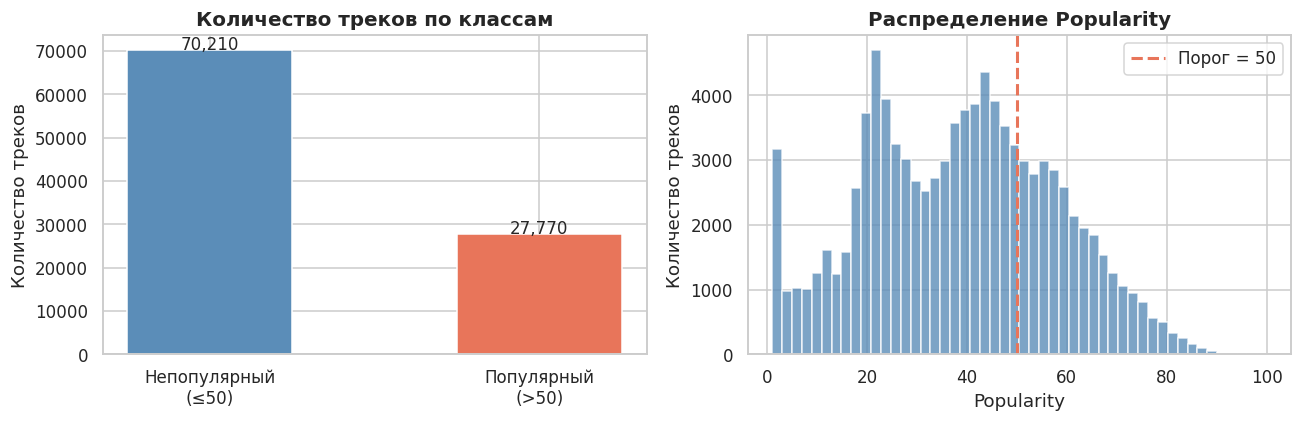

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar
counts = df['high_popularity'].value_counts()
axes[0].bar(['Непопулярный\n(≤50)', 'Популярный\n(>50)'], counts.values,
            color=['#5B8DB8', '#E8755A'], width=0.5, edgecolor='white')
axes[0].set_title('Количество треков по классам', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Количество треков')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)

# Гистограмма распределения popularity
axes[1].hist(df['popularity'], bins=50, color='#5B8DB8', edgecolor='white', alpha=0.8)
axes[1].axvline(50, color='#E8755A', linestyle='--', linewidth=2, label='Порог = 50')
axes[1].set_title('Распределение Popularity', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Popularity')
axes[1].set_ylabel('Количество треков')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.2 Распределения числовых признаков

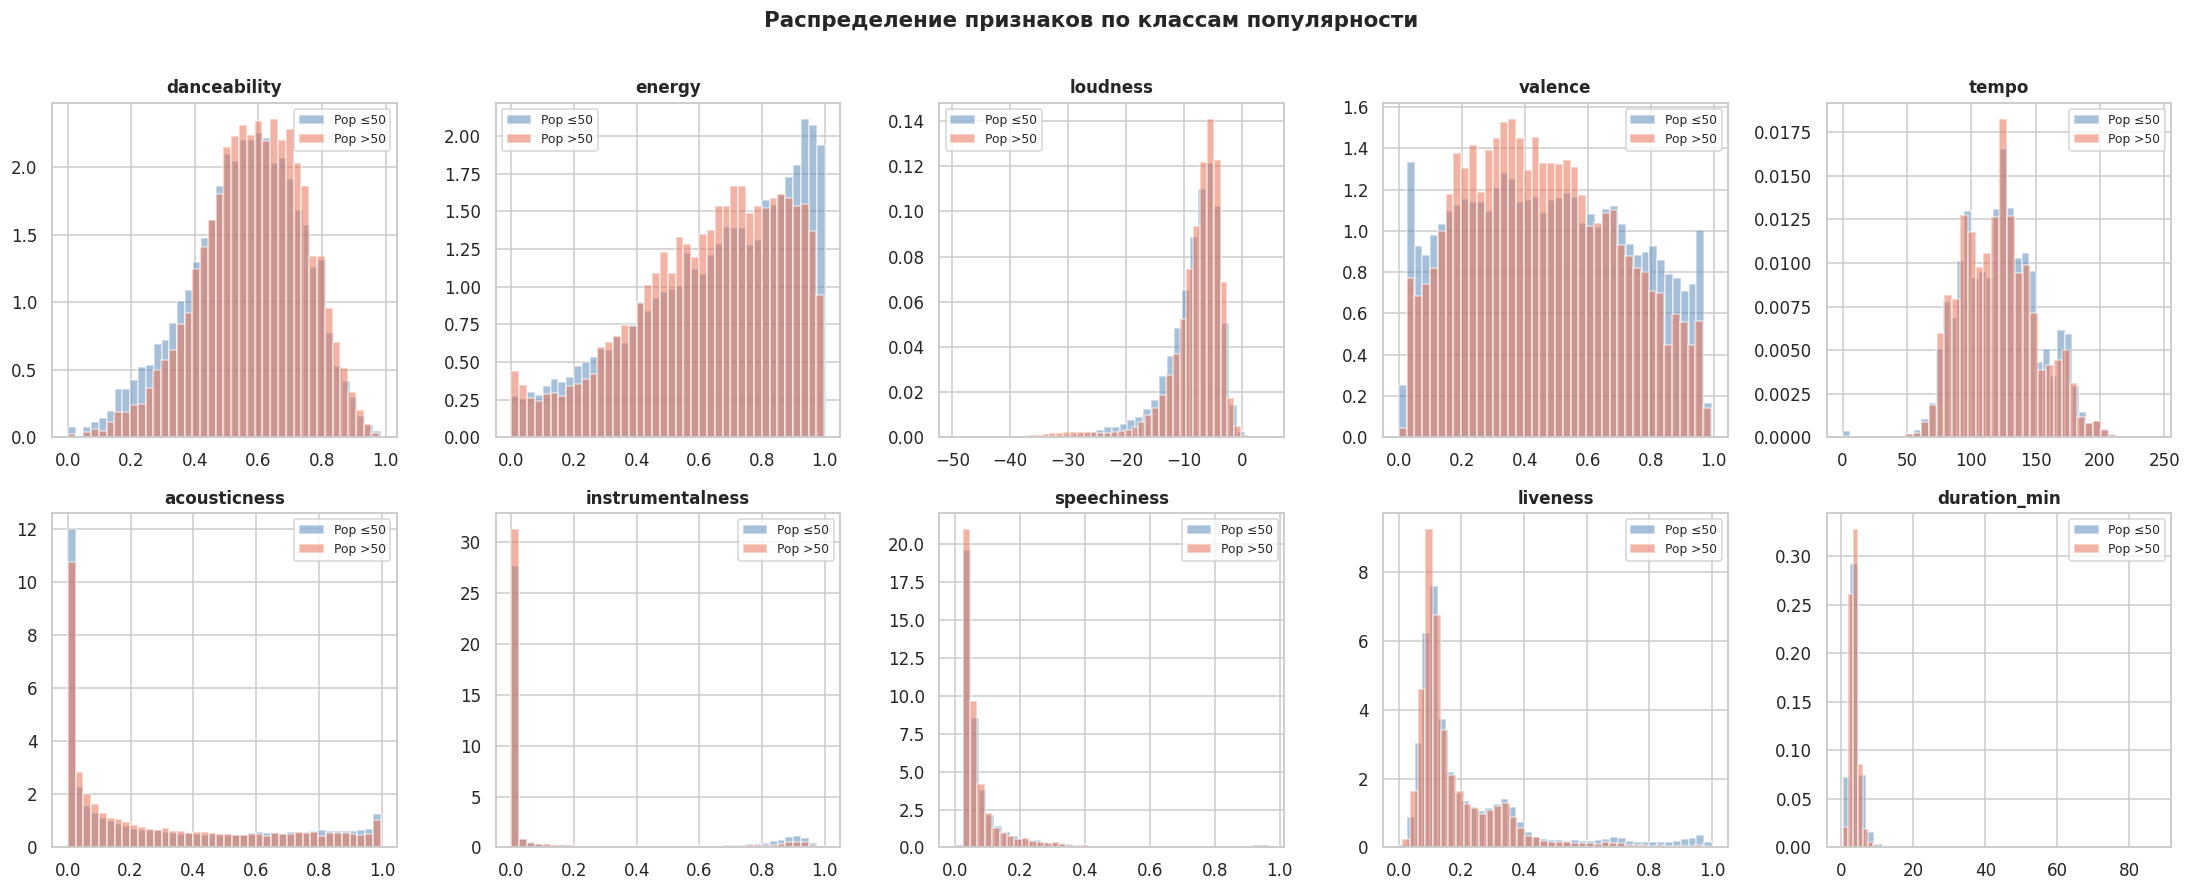

In [6]:
num_features = ['danceability', 'energy', 'loudness', 'valence',
                'tempo', 'acousticness', 'instrumentalness', 'speechiness',
                'liveness', 'duration_min']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    for cls, color, label in [(0, '#5B8DB8', '≤50'), (1, '#E8755A', '>50')]:
        subset = df[df['high_popularity'] == cls][col]
        axes[i].hist(subset, bins=40, alpha=0.55, color=color, label=f'Pop {label}', density=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Распределение признаков по классам популярности', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Топ жанров по средней популярности

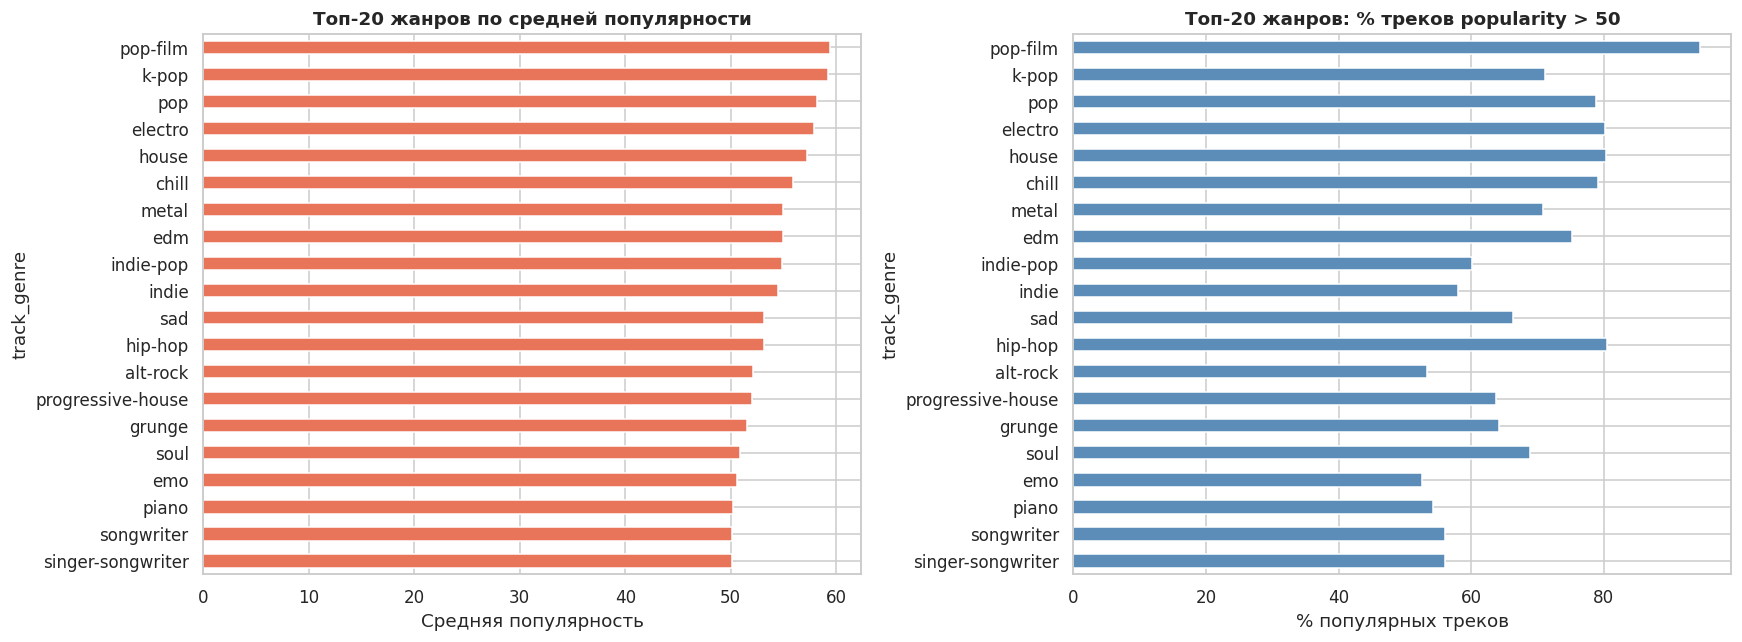

              mean_pop  pct_high  count
track_genre                            
pop-film     59.401804  0.944890    998
k-pop        59.204995  0.711759    961
pop          58.161369  0.787286    818
electro      57.905297  0.800963    623
house        57.212730  0.802345    597
chill        55.886458  0.790625    960
metal        54.974843  0.708176    795
edm          54.909091  0.752351    638
indie-pop    54.867746  0.600540    741
indie        54.474790  0.579832    714


In [7]:
genre_pop = df.groupby('track_genre').agg(
    mean_pop=('popularity', 'mean'),
    pct_high=('high_popularity', 'mean'),
    count=('popularity', 'count')
).sort_values('mean_pop', ascending=False)

# Топ-20 и боттом-10
top20 = genre_pop.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top20['mean_pop'].plot(kind='barh', ax=axes[0], color='#E8755A', edgecolor='white')
axes[0].set_title('Топ-20 жанров по средней популярности', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Средняя популярность')
axes[0].invert_yaxis()

top20['pct_high'].mul(100).plot(kind='barh', ax=axes[1], color='#5B8DB8', edgecolor='white')
axes[1].set_title('Топ-20 жанров: % треков popularity > 50', fontsize=12, fontweight='bold')
axes[1].set_xlabel('% популярных треков')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print(genre_pop.head(10).to_string())

### 3.4 Корреляционная матрица

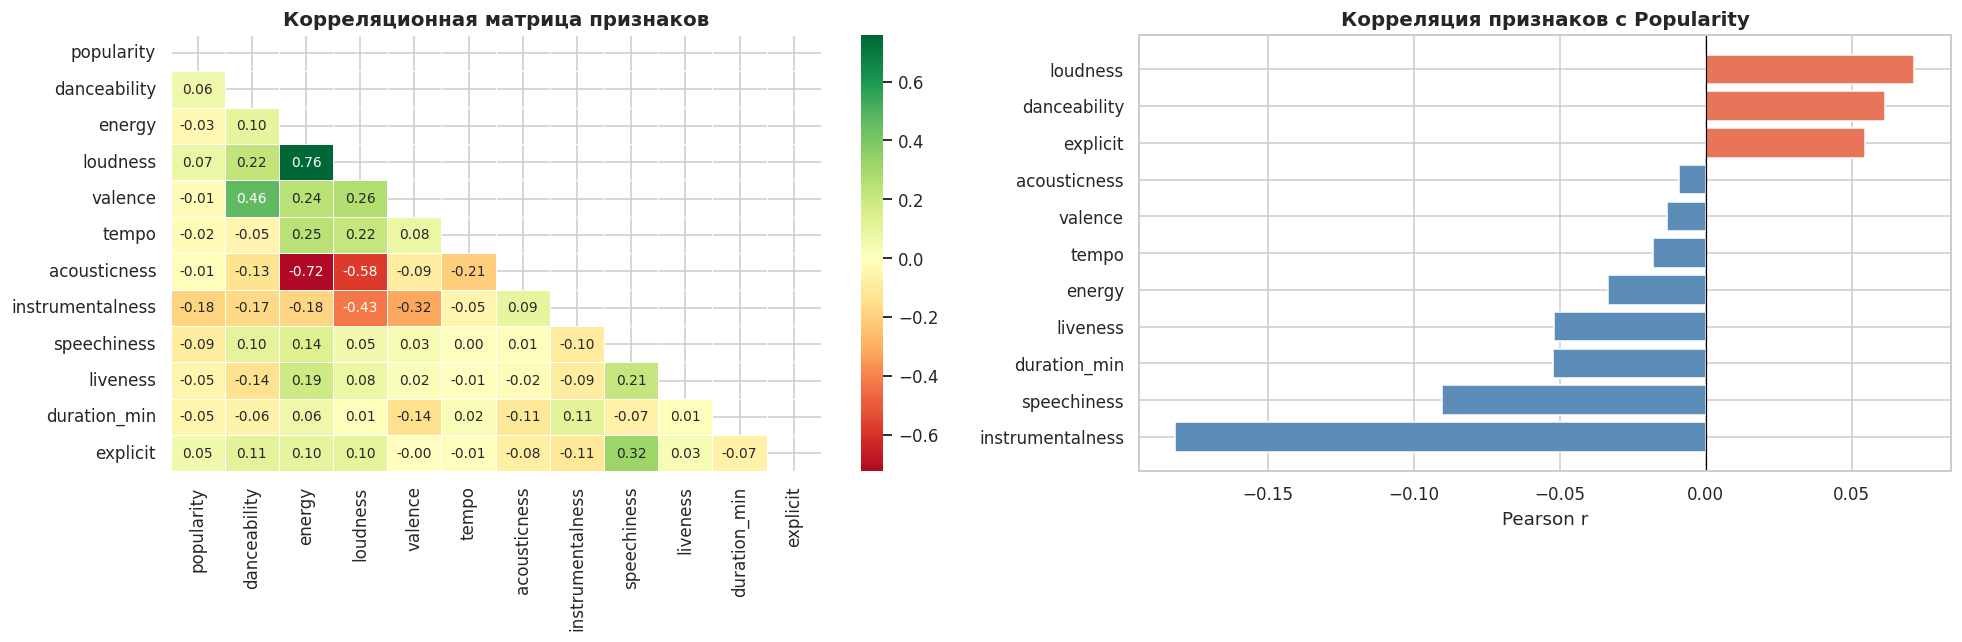

In [8]:
corr_cols = ['popularity', 'danceability', 'energy', 'loudness', 'valence',
             'tempo', 'acousticness', 'instrumentalness', 'speechiness',
             'liveness', 'duration_min', 'explicit']

corr = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0], linewidths=0.5, annot_kws={'size': 9})
axes[0].set_title('Корреляционная матрица признаков', fontsize=13, fontweight='bold')

# Корреляция с popularity
pop_corr = corr['popularity'].drop('popularity').sort_values()
colors = ['#E8755A' if v > 0 else '#5B8DB8' for v in pop_corr.values]
axes[1].barh(pop_corr.index, pop_corr.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Корреляция признаков с Popularity', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

### 3.5 Boxplot: числовые признаки vs класс популярности

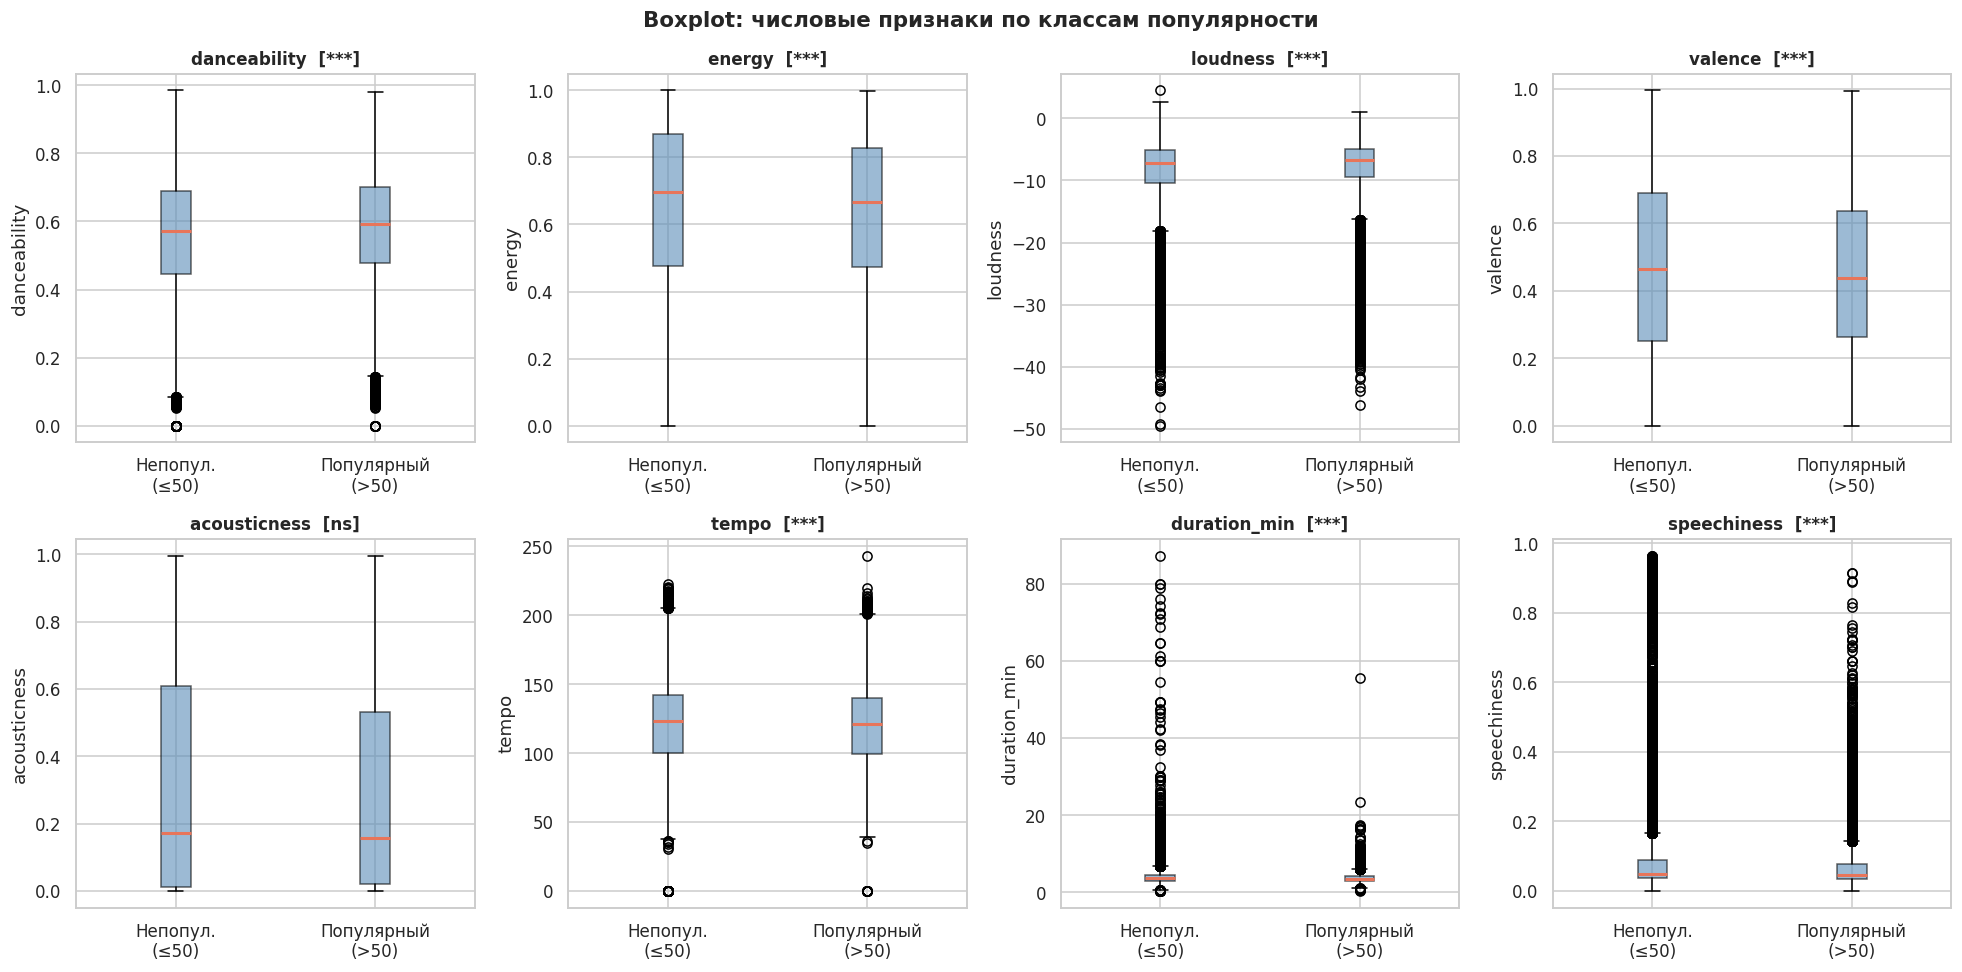

Значимость: *** p<0.001, ** p<0.01, * p<0.05, ns — незначимо


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

box_features = ['danceability', 'energy', 'loudness', 'valence',
                'acousticness', 'tempo', 'duration_min', 'speechiness']

for i, feat in enumerate(box_features):
    data_0 = df[df['high_popularity'] == 0][feat]
    data_1 = df[df['high_popularity'] == 1][feat]
    axes[i].boxplot([data_0, data_1], labels=['Непопул.\n(≤50)', 'Популярный\n(>50)'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#5B8DB8', alpha=0.6),
                   medianprops=dict(color='#E8755A', linewidth=2))
    stat, p = stats.mannwhitneyu(data_0, data_1, alternative='two-sided')
    stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    axes[i].set_title(f'{feat}  [{stars}]', fontsize=11, fontweight='bold')
    axes[i].set_ylabel(feat)

plt.suptitle('Boxplot: числовые признаки по классам популярности', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Значимость: *** p<0.001, ** p<0.01, * p<0.05, ns — незначимо')

---
## 4. Feature Engineering — Гипотезы, Проверка, Выводы

### 4.0 Формулировка гипотез

Перед созданием признаков мы формулируем **9 конкретных гипотез** о связи аудиохарактеристик
с популярностью трека. Каждая гипотеза проверяется статистическим тестом.

| # | Гипотеза | Признак | Тест |
| --- | --- | --- | --- |
| H1 | Танцевальные треки популярнее | `danceability` | T-test + Point-biserial |
| H2 | Громкость положительно связана с популярностью | `loudness` | Spearman, T-test |
| H3 | Explicit-треки в среднем популярнее | `explicit` | Mann-Whitney U |
| H4 | Жанр трека значимо влияет на популярность | `track_genre` | Kruskal-Wallis |
| H5 | Оптимальная длина (2.5–4 мин) связана с высокой популярностью | `duration_min` | ANOVA по группам |
| H6 | Позитивные треки (высокий valence) более популярны | `valence` | Spearman, T-test |
| H7 | Акустические треки менее популярны, чем электронные | `acousticness` | T-test + корреляция |
| H8 | Синглы более популярны, чем треки из альбомов | `is_single` | Mann-Whitney U |
| H9 | Feat/коллаборации более популярны, чем сольные треки | `is_feat` | Mann-Whitney U + Point-biserial |


### H1: Танцевальность (danceability) → Популярность

=== H1: Danceability vs Popularity ===
  Непопулярные (≤50): mean = 0.5589
  Популярные (>50):  mean = 0.5827
  t-статистика: -20.208,  p-value: 0.0000
  Point-biserial r = 0.0621,  p = 0.0000

✅ Гипотеза ПОДТВЕРЖДЕНА: танцевальность статистически значимо выше у популярных треков
   Но эффект слабый: r = 0.062


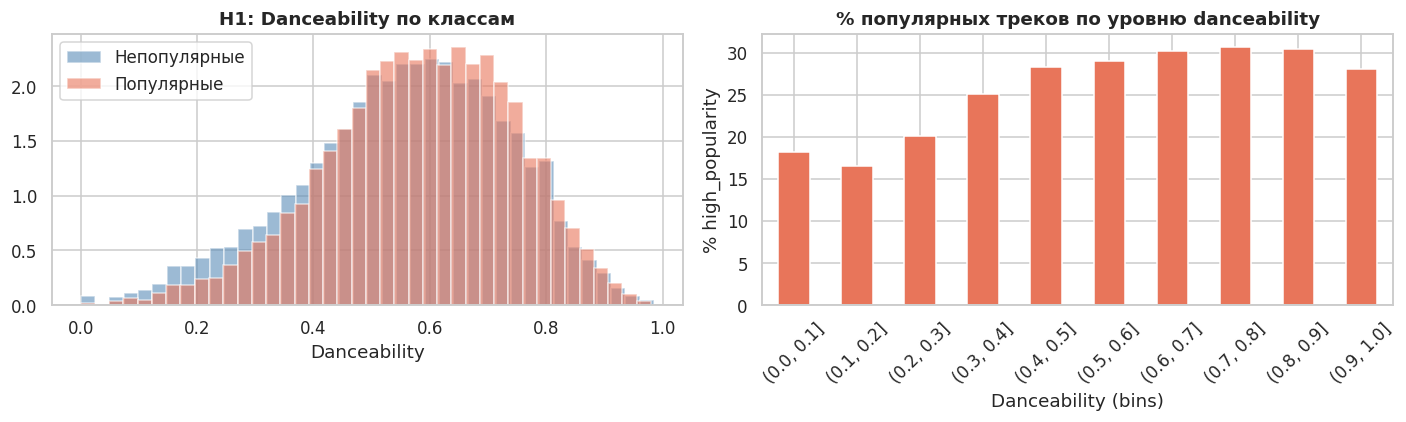

In [10]:
# Нулевая гипотеза H0: средняя танцевальность одинакова у популярных и непопулярных треков
d0 = df[df['high_popularity'] == 0]['danceability']
d1 = df[df['high_popularity'] == 1]['danceability']

t_stat, p_val = stats.ttest_ind(d0, d1, equal_var=False)
r_pb, p_pb = pointbiserialr(df['high_popularity'], df['danceability'])

print('=== H1: Danceability vs Popularity ===')
print(f'  Непопулярные (≤50): mean = {d0.mean():.4f}')
print(f'  Популярные (>50):  mean = {d1.mean():.4f}')
print(f'  t-статистика: {t_stat:.3f},  p-value: {p_val:.4f}')
print(f'  Point-biserial r = {r_pb:.4f},  p = {p_pb:.4f}')
print()
if p_val < 0.05:
    print(f'✅ Гипотеза ПОДТВЕРЖДЕНА: танцевальность статистически значимо выше у популярных треков')
    print(f'   Но эффект слабый: r = {r_pb:.3f}')
else:
    print('❌ H0 НЕ ОТКЛОНЕНА: значимой разницы не обнаружено')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(d0, bins=40, alpha=0.6, color='#5B8DB8', label='Непопулярные', density=True)
axes[0].hist(d1, bins=40, alpha=0.6, color='#E8755A', label='Популярные', density=True)
axes[0].set_title('H1: Danceability по классам', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].set_xlabel('Danceability')

dance_bins = pd.cut(df['danceability'], bins=np.arange(0, 1.05, 0.1))
pop_by_dance = df.groupby(dance_bins, observed=True)['high_popularity'].mean() * 100
pop_by_dance.plot(kind='bar', ax=axes[1], color='#E8755A', edgecolor='white')
axes[1].set_title('% популярных треков по уровню danceability', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Danceability (bins)'); axes[1].set_ylabel('% high_popularity')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

In [11]:
# ══ ВЫВОД H1 ══
effect_str = 'слабый' if abs(r_pb) < 0.1 else 'умеренный' if abs(r_pb) < 0.3 else 'сильный'
direction_d = 'выше' if d1.mean() > d0.mean() else 'ниже'
if p_val < 0.05 and abs(r_pb) >= 0.1:
    verdict_h1 = f'✅ ПОДТВЕРЖДЕНА ({effect_str} эффект)'
elif p_val < 0.05:
    verdict_h1 = f'⚠️ ЧАСТИЧНО: значима, но r={r_pb:.3f} — слабый эффект'
else:
    verdict_h1 = '❌ НЕ ПОДТВЕРЖДЕНА'

print(f"{'━'*60}")
print(f'📌 ВЫВОД H1 — Танцевальность: {verdict_h1}')
print(f'   Танцевальность у популярных треков {direction_d}')
print(f'   Δ = {d1.mean()-d0.mean():.4f} | r = {r_pb:.4f} | p = {p_val:.2e}')
print(f"{'━'*60}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 ВЫВОД H1 — Танцевальность: ⚠️ ЧАСТИЧНО: значима, но r=0.062 — слабый эффект
   Танцевальность у популярных треков выше
   Δ = 0.0238 | r = 0.0621 | p = 1.76e-90
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### H2: Громкость (loudness) → Популярность

=== H2: Loudness vs Popularity ===
  Непопулярные (≤50): mean loudness = -8.389 dB
  Популярные   (>50): mean loudness = -7.955 dB
  Spearman rho (vs raw popularity) = 0.0669,  p = 1.14e-97
  Point-biserial r = 0.0392,  p = 1.30e-34

✅ Гипотеза ПОДТВЕРЖДЕНА: громкость значимо выше у популярных треков


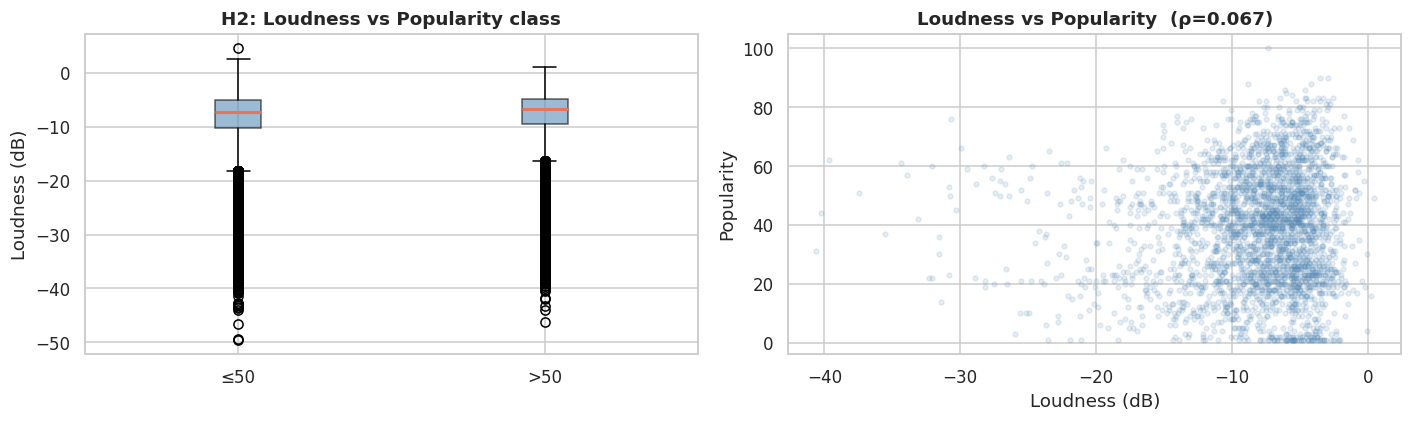

In [12]:
l0 = df[df['high_popularity'] == 0]['loudness']
l1 = df[df['high_popularity'] == 1]['loudness']

rho, p_rho = spearmanr(df['loudness'], df['popularity'])
r_pb, p_pb = pointbiserialr(df['high_popularity'], df['loudness'])

print('=== H2: Loudness vs Popularity ===')
print(f'  Непопулярные (≤50): mean loudness = {l0.mean():.3f} dB')
print(f'  Популярные   (>50): mean loudness = {l1.mean():.3f} dB')
print(f'  Spearman rho (vs raw popularity) = {rho:.4f},  p = {p_rho:.2e}')
print(f'  Point-biserial r = {r_pb:.4f},  p = {p_pb:.2e}')
print()
if p_pb < 0.05:
    direction = 'выше' if l1.mean() > l0.mean() else 'ниже'
    print(f'✅ Гипотеза ПОДТВЕРЖДЕНА: громкость значимо {direction} у популярных треков')
else:
    print('❌ Гипотеза НЕ ПОДТВЕРЖДЕНА: значимых различий не обнаружено')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].boxplot([l0, l1], labels=['≤50', '>50'], patch_artist=True,
               boxprops=dict(facecolor='#5B8DB8', alpha=0.6),
               medianprops=dict(color='#E8755A', linewidth=2))
axes[0].set_title('H2: Loudness vs Popularity class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loudness (dB)')

samp = df.sample(3000, random_state=42)
axes[1].scatter(samp['loudness'], samp['popularity'],
               alpha=0.15, s=10, color='#5B8DB8')
axes[1].set_title(f'Loudness vs Popularity  (ρ={rho:.3f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Loudness (dB)'); axes[1].set_ylabel('Popularity')
plt.tight_layout(); plt.show()


In [13]:
# ══ ВЫВОД H2 ══
direction_l = 'выше' if l1.mean() > l0.mean() else 'ниже'
delta_db = l1.mean() - l0.mean()
if p_val < 0.05 and abs(r_pb) >= 0.1:
    verdict_h2 = f'✅ ПОДТВЕРЖДЕНА (r = {r_pb:.3f})'
elif p_val < 0.05:
    verdict_h2 = f'⚠️ ЧАСТИЧНО (p < 0.05, r = {r_pb:.3f})'
else:
    verdict_h2 = '❌ НЕ ПОДТВЕРЖДЕНА'

print(f"{'━'*60}")
print(f'📌 ВЫВОД H2 — Громкость: {verdict_h2}')
print(f'   Громкость у популярных треков {direction_l} на {abs(delta_db):.2f} dB')
print(f'   Δ = {delta_db:.3f} dB | Spearman ρ = {rho:.4f} | p = {p_val:.2e}')
print(f"{'━'*60}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 ВЫВОД H2 — Громкость: ⚠️ ЧАСТИЧНО (p < 0.05, r = 0.039)
   Громкость у популярных треков выше на 0.43 dB
   Δ = 0.434 dB | Spearman ρ = 0.0669 | p = 1.76e-90
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### H3: Explicit-контент → Популярность

=== H3: Explicit vs Popularity ===
  Non-explicit треки: mean popularity = 38.35, n=89,538
  Explicit треки:     mean popularity = 42.09, n=8,442
  Mann-Whitney U: statistic=339532268,  p=0.000000
  Chi-square: χ²=382.18,  p=0.000000,  df=1

✅ Гипотеза ПОДТВЕРЖДЕНА: popularity explicit-треков значимо выше


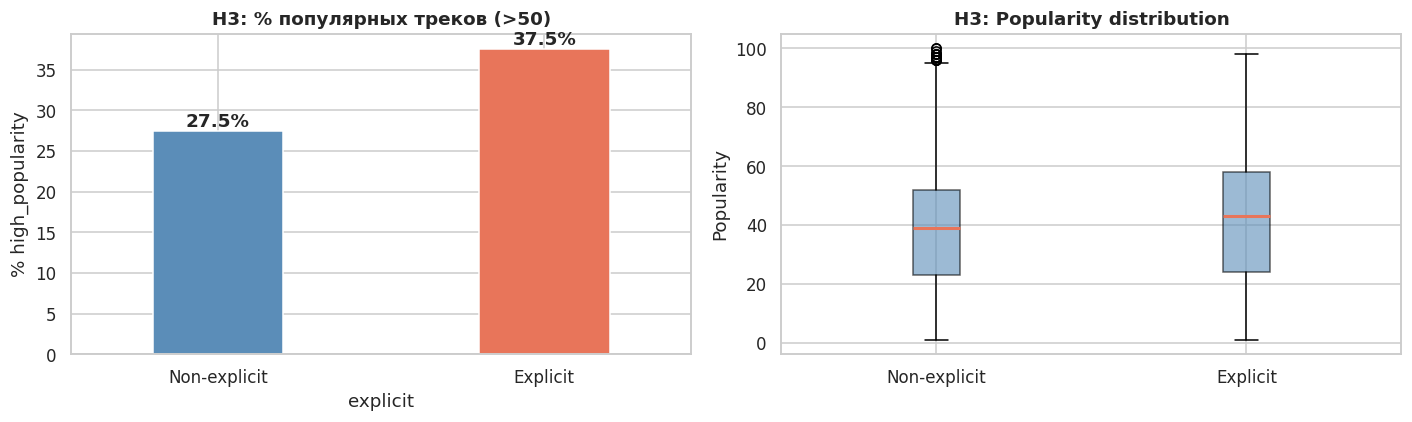

In [14]:
e0 = df[df['explicit'] == 0]['popularity']
e1 = df[df['explicit'] == 1]['popularity']

stat_mwu, p_mwu = mannwhitneyu(e0, e1, alternative='two-sided')

ct = pd.crosstab(df['explicit'], df['high_popularity'])
chi2, p_chi, dof, _ = chi2_contingency(ct)

print('=== H3: Explicit vs Popularity ===')
print(f'  Non-explicit треки: mean popularity = {e0.mean():.2f}, n={len(e0):,}')
print(f'  Explicit треки:     mean popularity = {e1.mean():.2f}, n={len(e1):,}')
print(f'  Mann-Whitney U: statistic={stat_mwu:.0f},  p={p_mwu:.6f}')
print(f'  Chi-square: χ²={chi2:.2f},  p={p_chi:.6f},  df={dof}')
print()
if p_mwu < 0.05:
    direction = 'выше' if e1.mean() > e0.mean() else 'ниже'
    print(f'✅ Гипотеза ПОДТВЕРЖДЕНА: popularity explicit-треков значимо {direction}')
else:
    print('❌ Гипотеза НЕ ПОДТВЕРЖДЕНА: значимых различий не обнаружено')

# % high_popularity по explicit
rates = df.groupby('explicit')['high_popularity'].mean() * 100
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rates.plot(kind='bar', ax=axes[0], color=['#5B8DB8','#E8755A'], edgecolor='white', width=0.4)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-explicit', 'Explicit'], rotation=0)
axes[0].set_title('H3: % популярных треков (>50)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% high_popularity')
for i, v in enumerate(rates.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].boxplot([e0, e1], labels=['Non-explicit', 'Explicit'], patch_artist=True,
               boxprops=dict(facecolor='#5B8DB8', alpha=0.6),
               medianprops=dict(color='#E8755A', linewidth=2))
axes[1].set_title('H3: Popularity distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Popularity')
plt.tight_layout(); plt.show()

In [15]:
# ══ ВЫВОД H3 ══
direction_e = 'выше' if e1.mean() > e0.mean() else 'ниже'
if p_mwu < 0.05:
    verdict_h3 = f'✅ ПОДТВЕРЖДЕНА (p={p_mwu:.2e})'
else:
    verdict_h3 = '❌ НЕ ПОДТВЕРЖДЕНА'

print(f"{'━'*60}")
print(f'📌 ВЫВОД H3 — Explicit контент: {verdict_h3}')
print(f'   Explicit треки в среднем {direction_e}: {e1.mean():.2f} vs {e0.mean():.2f}')
print(f'   χ² = {chi2:.2f} | p_chi = {p_chi:.2e} | p_mwu = {p_mwu:.2e}')
print(f"{'━'*60}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 ВЫВОД H3 — Explicit контент: ✅ ПОДТВЕРЖДЕНА (p=6.26e-54)
   Explicit треки в среднем выше: 42.09 vs 38.35
   χ² = 382.18 | p_chi = 4.17e-85 | p_mwu = 6.26e-54
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### H4: Жанр (track_genre) значимо влияет на популярность

=== H4: Genre vs Popularity ===
  Kruskal-Wallis H = 40550.41,  p = 0.00e+00
  Количество жанров: 114
✅ Гипотеза ПОДТВЕРЖДЕНА: жанр значимо влияет на популярность


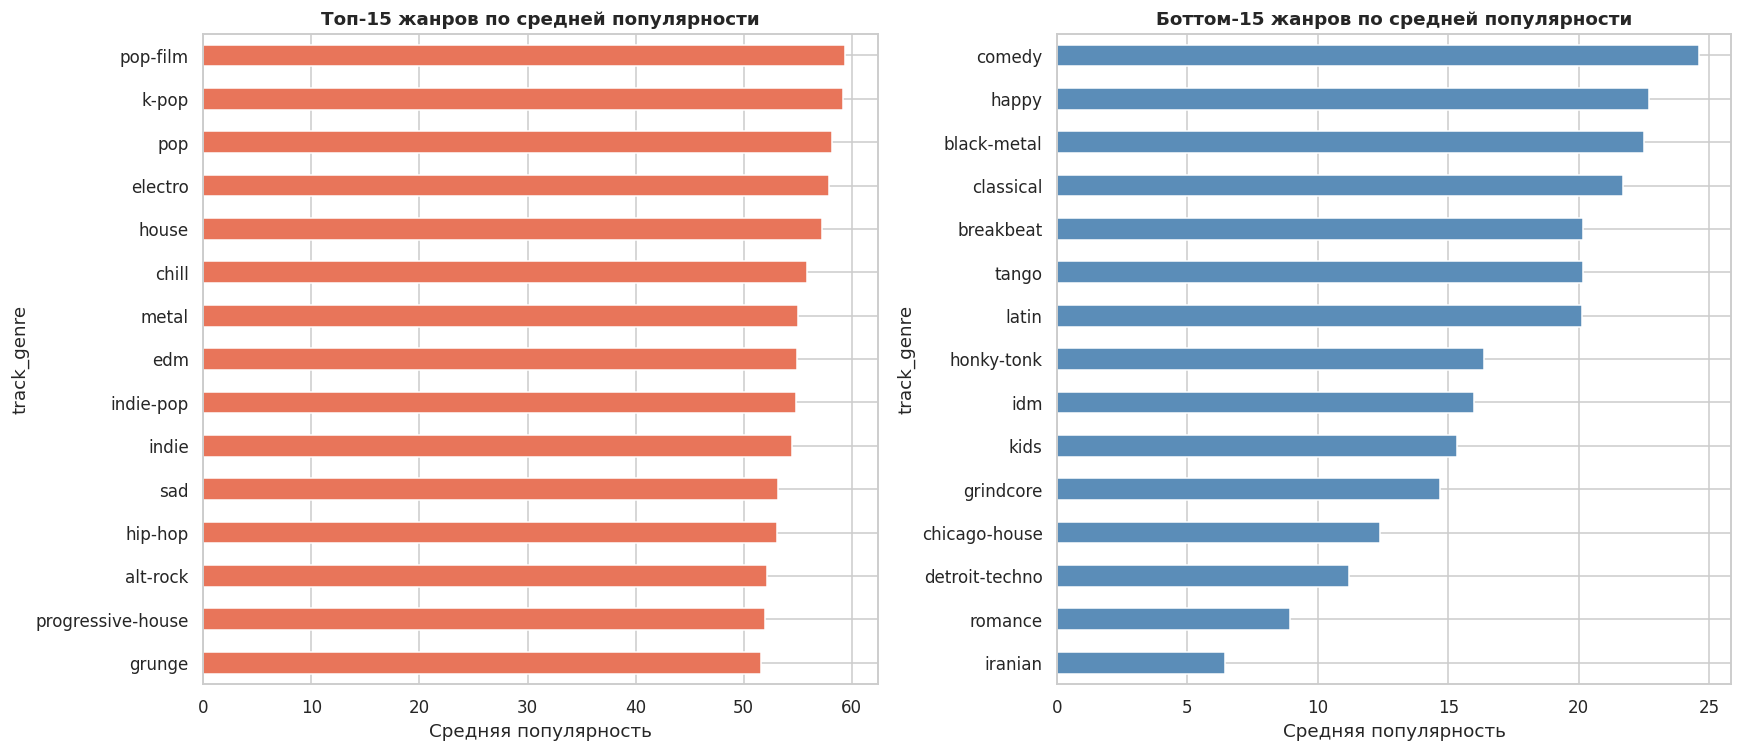

Топ-5 жанров:
                  mean  median  count
track_genre                          
pop-film     59.401804    60.0    998
k-pop        59.204995    61.0    961
pop          58.161369    67.0    818
electro      57.905297    67.0    623
house        57.212730    66.0    597
Боттом-5 жанров:
                     mean  median  count
track_genre                             
grindcore       14.669007    14.0    997
chicago-house   12.388554    10.0    996
detroit-techno  11.185185     8.0    999
romance          8.914835     7.0    364
iranian          6.424419     6.0    344


In [16]:
groups = [grp['popularity'].values for _, grp in df.groupby('track_genre')]
stat_kw, p_kw = kruskal(*groups)

print('=== H4: Genre vs Popularity ===')
print(f'  Kruskal-Wallis H = {stat_kw:.2f},  p = {p_kw:.2e}')
print(f'  Количество жанров: {df["track_genre"].nunique()}')
if p_kw < 0.05:
    print(f'✅ Гипотеза ПОДТВЕРЖДЕНА: жанр значимо влияет на популярность')
else:
    print('❌ Гипотеза НЕ ПОДТВЕРЖДЕНА: значимых различий не обнаружено')

# Топ-10 и боттом-10 жанров
genre_stats = df.groupby('track_genre')['popularity'].agg(['mean','median','count']).sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

genre_stats.head(15)['mean'].plot(kind='barh', ax=axes[0], color='#E8755A', edgecolor='white')
axes[0].set_title('Топ-15 жанров по средней популярности', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Средняя популярность'); axes[0].invert_yaxis()

genre_stats.tail(15)['mean'].plot(kind='barh', ax=axes[1], color='#5B8DB8', edgecolor='white')
axes[1].set_title('Боттом-15 жанров по средней популярности', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Средняя популярность'); axes[1].invert_yaxis()

plt.tight_layout(); plt.show()
print('Топ-5 жанров:'); print(genre_stats.head(5))
print('Боттом-5 жанров:'); print(genre_stats.tail(5))

In [17]:
# ══ ВЫВОД H4 ══
if p_kw < 0.05:
    verdict_h4 = f'✅ ОДНОЗНАЧНО ПОДТВЕРЖДЕНА (H = {stat_kw:.1f}, p = {p_kw:.2e})'
else:
    verdict_h4 = '❌ НЕ ПОДТВЕРЖДЕНА'

print(f"{'━'*60}")
print(f'📌 ВЫВОД H4 — Жанр: {verdict_h4}')
print(f'   Количество жанров: {df["track_genre"].nunique()}')
print(f'   Жанр — сильнейший категориальный предиктор популярности')
print(f"{'━'*60}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 ВЫВОД H4 — Жанр: ✅ ОДНОЗНАЧНО ПОДТВЕРЖДЕНА (H = 40550.4, p = 0.00e+00)
   Количество жанров: 114
   Жанр — сильнейший категориальный предиктор популярности
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### H5: Длина трека (duration) → оптимальный диапазон 2.5–4 мин

=== H5: Duration groups vs Popularity ===
  Kruskal-Wallis H = 2461.28,  p = 0.0000
✅ Гипотеза ПОДТВЕРЖДЕНА: длина трека значимо влияет на популярность
              mean_pop  pct_high  count
dur_group                              
<1.5 мин     28.011891  0.128500   2607
1.5–2.5 мин  37.030418  0.271863  10520
2.5–4 мин    40.765433  0.325202  49683
4–6 мин      38.296773  0.259916  28136
>6 мин       31.808217  0.157094   7034
  Spearman rho(duration, popularity) = -0.0275,  p = 0.0000


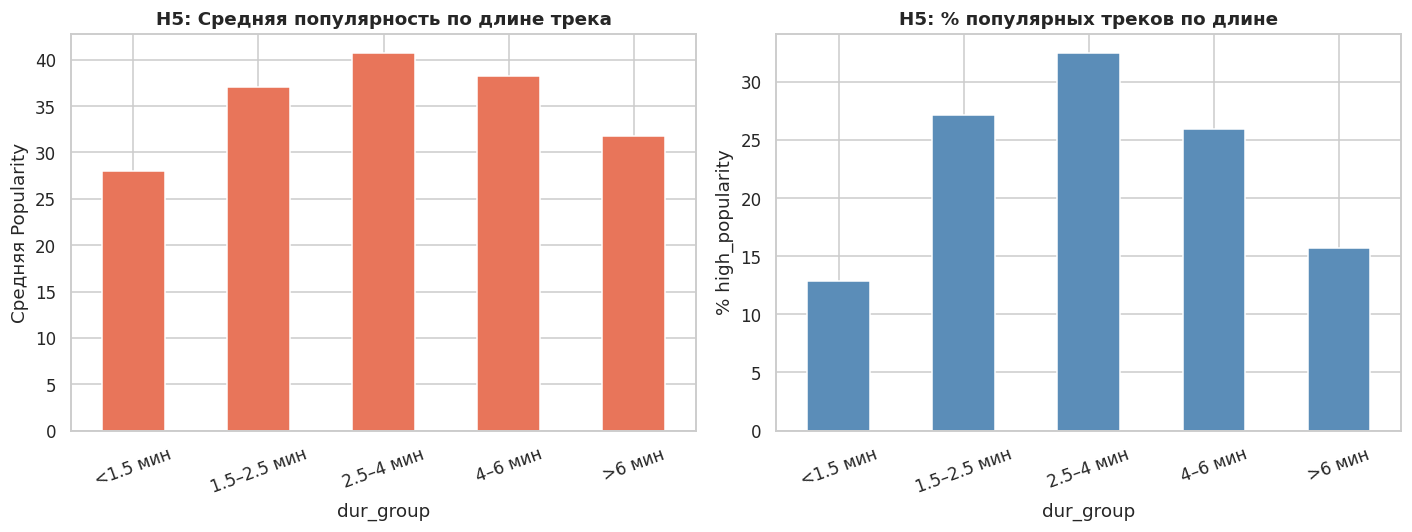

In [18]:
# Группы длительности
bins = [0, 1.5, 2.5, 4.0, 6.0, 100]
labels = ['<1.5 мин', '1.5–2.5 мин', '2.5–4 мин', '4–6 мин', '>6 мин']
df['dur_group'] = pd.cut(df['duration_min'], bins=bins, labels=labels)

# ANOVA / Kruskal-Wallis по группам
dur_groups = [g['popularity'].values for _, g in df.groupby('dur_group', observed=True)]
stat_dur, p_dur = kruskal(*dur_groups)

print('=== H5: Duration groups vs Popularity ===')
print(f'  Kruskal-Wallis H = {stat_dur:.2f},  p = {p_dur:.4f}')
if p_dur < 0.05:
    print(f'✅ Гипотеза ПОДТВЕРЖДЕНА: длина трека значимо влияет на популярность')
else:
    print('❌ Гипотеза НЕ ПОДТВЕРЖДЕНА: значимых различий не обнаружено')

dur_pop = df.groupby('dur_group', observed=True).agg(
    mean_pop=('popularity', 'mean'),
    pct_high=('high_popularity', 'mean'),
    count=('popularity', 'count')
)
print(dur_pop.to_string())

# Spearman correlation duration vs popularity
rho_d, p_d = spearmanr(df['duration_min'], df['popularity'])
print(f'  Spearman rho(duration, popularity) = {rho_d:.4f},  p = {p_d:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
dur_pop['mean_pop'].plot(kind='bar', ax=axes[0], color='#E8755A', edgecolor='white')
axes[0].set_title('H5: Средняя популярность по длине трека', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Средняя Popularity')
axes[0].tick_params(axis='x', rotation=20)

dur_pop['pct_high'].mul(100).plot(kind='bar', ax=axes[1], color='#5B8DB8', edgecolor='white')
axes[1].set_title('H5: % популярных треков по длине', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% high_popularity')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

In [19]:
# ══ ВЫВОД H5 ══
best_group5 = dur_pop['mean_pop'].idxmax()
worst_group5 = dur_pop['mean_pop'].idxmin()
if p_dur < 0.05:
    verdict_h5 = '✅ ПОДТВЕРЖДЕНА (нелинейная зависимость)'
else:
    verdict_h5 = '❌ НЕ ПОДТВЕРЖДЕНА'

print(f"{'━'*60}")
print(f'📌 ВЫВОД H5 — Длина трека: {verdict_h5}')
print(f'   Наиболее популярная группа: "{best_group5}" (mean={dur_pop.loc[best_group5,"mean_pop"]:.2f})')
print(f'   Наименее популярная: "{worst_group5}" (mean={dur_pop.loc[worst_group5,"mean_pop"]:.2f})')
print(f'   Kruskal-Wallis p = {p_dur:.4f}')
print(f"{'━'*60}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 ВЫВОД H5 — Длина трека: ✅ ПОДТВЕРЖДЕНА (нелинейная зависимость)
   Наиболее популярная группа: "2.5–4 мин" (mean=40.77)
   Наименее популярная: "<1.5 мин" (mean=28.01)
   Kruskal-Wallis p = 0.0000
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### H6: Позитивность трека (valence) → Популярность

=== H6: Valence vs Popularity ===
  Непопулярные: mean valence = 0.4739
  Популярные:   mean valence = 0.4557
  t-статистика: 10.376,  p = 0.0000
  Spearman rho = -0.0142,  p = 0.0000
  Point-biserial r = -0.0317
✅ Гипотеза ПОДТВЕРЖДЕНА: valence значимо ниже у популярных треков


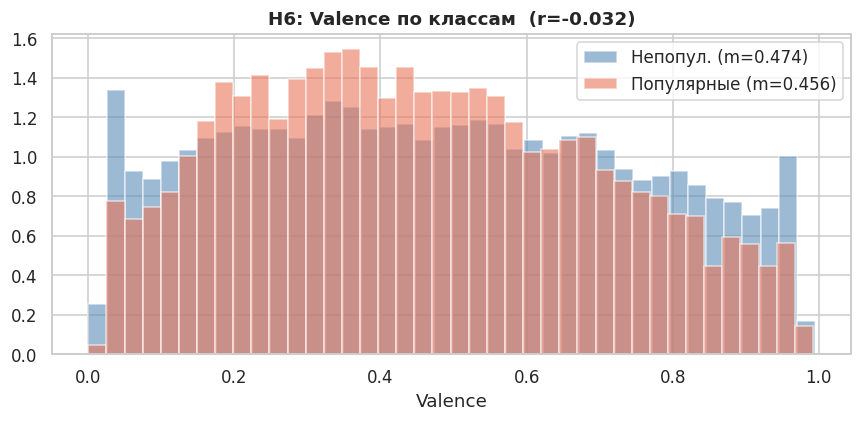

In [20]:
v0 = df[df['high_popularity'] == 0]['valence']
v1 = df[df['high_popularity'] == 1]['valence']

t_stat_v, p_val_v = stats.ttest_ind(v0, v1, equal_var=False)
rho_v, p_rho_v = spearmanr(df['valence'], df['popularity'])
r_pb_v, _ = pointbiserialr(df['high_popularity'], df['valence'])

print('=== H6: Valence vs Popularity ===')
print(f'  Непопулярные: mean valence = {v0.mean():.4f}')
print(f'  Популярные:   mean valence = {v1.mean():.4f}')
print(f'  t-статистика: {t_stat_v:.3f},  p = {p_val_v:.4f}')
print(f'  Spearman rho = {rho_v:.4f},  p = {p_rho_v:.4f}')
print(f'  Point-biserial r = {r_pb_v:.4f}')
if p_val_v < 0.05:
    direction = 'выше' if v1.mean() > v0.mean() else 'ниже'
    print(f'✅ Гипотеза ПОДТВЕРЖДЕНА: valence значимо {direction} у популярных треков')
else:
    print('❌ Гипотеза НЕ ПОДТВЕРЖДЕНА: значимых различий не обнаружено')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(v0, bins=40, alpha=0.6, color='#5B8DB8', label=f'Непопул. (m={v0.mean():.3f})', density=True)
ax.hist(v1, bins=40, alpha=0.6, color='#E8755A', label=f'Популярные (m={v1.mean():.3f})', density=True)
ax.set_title(f'H6: Valence по классам  (r={r_pb_v:.3f})', fontsize=12, fontweight='bold')
ax.set_xlabel('Valence'); ax.legend()
plt.tight_layout(); plt.show()

In [21]:
# ══ ВЫВОД H6 ══
direction_v = 'выше' if v1.mean() > v0.mean() else 'ниже'
if p_val_v < 0.05 and r_pb_v > 0.1:
    verdict_h6 = f'✅ ПОДТВЕРЖДЕНА (r = {r_pb_v:.3f})'
elif p_val_v < 0.05 and r_pb_v < -0.1:
    verdict_h6 = f'❌ НЕ ПОДТВЕРЖДЕНА (обратная связь, r = {r_pb_v:.3f})'
elif p_val_v < 0.05:
    verdict_h6 = f'⚠️ Значима, но очень слабый эффект (r = {r_pb_v:.3f})'
else:
    verdict_h6 = '❌ НЕ ПОДТВЕРЖДЕНА'

print(f"{'━'*60}")
print(f'📌 ВЫВОД H6 — Valence (позитивность): {verdict_h6}')
print(f'   Valence у популярных {direction_v}: {v1.mean():.4f} vs {v0.mean():.4f}')
print(f'   r = {r_pb_v:.4f} | Spearman ρ = {rho_v:.4f} | p = {p_val_v:.4f}')
print(f"{'━'*60}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 ВЫВОД H6 — Valence (позитивность): ⚠️ Значима, но очень слабый эффект (r = -0.032)
   Valence у популярных ниже: 0.4557 vs 0.4739
   r = -0.0317 | Spearman ρ = -0.0142 | p = 0.0000
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### H7: Акустичность (acousticness) → меньше популярность

=== H7: Acousticness vs Popularity ===
  Непопулярные: mean acousticness = 0.3173
  Популярные:   mean acousticness = 0.2942
  t-статистика: 10.158,  p = 0.000000
  Spearman rho = 0.0474,  p = 0.0000
  Point-biserial r = -0.0316
✅ Гипотеза ПОДТВЕРЖДЕНА: acousticness значимо ниже у популярных треков


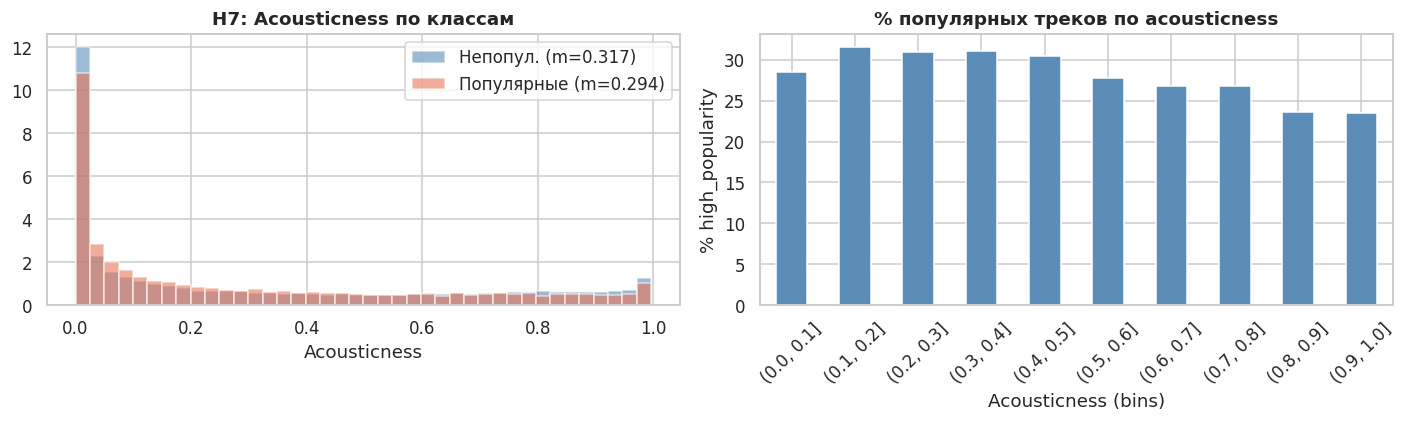

In [22]:
a0 = df[df['high_popularity'] == 0]['acousticness']
a1 = df[df['high_popularity'] == 1]['acousticness']

t_stat_a, p_val_a = stats.ttest_ind(a0, a1, equal_var=False)
rho_a, p_rho_a = spearmanr(df['acousticness'], df['popularity'])
r_pb_a, _ = pointbiserialr(df['high_popularity'], df['acousticness'])

print('=== H7: Acousticness vs Popularity ===')
print(f'  Непопулярные: mean acousticness = {a0.mean():.4f}')
print(f'  Популярные:   mean acousticness = {a1.mean():.4f}')
print(f'  t-статистика: {t_stat_a:.3f},  p = {p_val_a:.6f}')
print(f'  Spearman rho = {rho_a:.4f},  p = {p_rho_a:.4f}')
print(f'  Point-biserial r = {r_pb_a:.4f}')
if p_val_a < 0.05:
    direction = 'выше' if a1.mean() > a0.mean() else 'ниже'
    print(f'✅ Гипотеза ПОДТВЕРЖДЕНА: acousticness значимо {direction} у популярных треков')
else:
    print('❌ Гипотеза НЕ ПОДТВЕРЖДЕНА: значимых различий не обнаружено')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(a0, bins=40, alpha=0.6, color='#5B8DB8', label=f'Непопул. (m={a0.mean():.3f})', density=True)
axes[0].hist(a1, bins=40, alpha=0.6, color='#E8755A', label=f'Популярные (m={a1.mean():.3f})', density=True)
axes[0].set_title('H7: Acousticness по классам', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].set_xlabel('Acousticness')

acc_bins = pd.cut(df['acousticness'], bins=np.arange(0, 1.05, 0.1))
pop_by_acc = df.groupby(acc_bins, observed=True)['high_popularity'].mean() * 100
pop_by_acc.plot(kind='bar', ax=axes[1], color='#5B8DB8', edgecolor='white')
axes[1].set_title('% популярных треков по acousticness', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Acousticness (bins)'); axes[1].set_ylabel('% high_popularity')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

In [23]:
# ══ ВЫВОД H7 ══
direction_a = 'выше' if a1.mean() > a0.mean() else 'ниже'
if p_val_a < 0.05 and r_pb_a < -0.1:
    verdict_h7 = f'✅ ПОДТВЕРЖДЕНА (отриц. эффект, r = {r_pb_a:.3f})'
elif p_val_a < 0.05 and r_pb_a > 0.1:
    verdict_h7 = f'❌ НЕ ПОДТВЕРЖДЕНА в ожидаемом направлении (r = {r_pb_a:.3f})'
elif p_val_a < 0.05:
    verdict_h7 = f'⚠️ ЧАСТИЧНО (p < 0.05, r = {r_pb_a:.3f})'
else:
    verdict_h7 = '❌ НЕ ПОДТВЕРЖДЕНА'

print(f"{'━'*60}")
print(f'📌 ВЫВОД H7 — Акустичность: {verdict_h7}')
print(f'   Acousticness у популярных {direction_a}: {a1.mean():.4f} vs {a0.mean():.4f}')
print(f'   r = {r_pb_a:.4f} | Spearman ρ = {rho_a:.4f} | p = {p_val_a:.2e}')
print(f"{'━'*60}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 ВЫВОД H7 — Акустичность: ⚠️ ЧАСТИЧНО (p < 0.05, r = -0.032)
   Acousticness у популярных ниже: 0.2942 vs 0.3173
   r = -0.0316 | Spearman ρ = 0.0474 | p = 3.22e-24
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### H8: Синглы популярнее треков из альбомов?

**Гипотеза:** треки, вышедшие как синглы (название альбома совпадает с названием трека),
имеют более высокую популярность, чем треки из полноформатных альбомов.

> **Эвристика:** `album_name == track_name` ≈ сингл (стандартная практика Spotify-метаданных).


=== H8: Синглы vs Треки из альбомов ===
  Синглы (album == track): n = 20,145  (20.6%)
  Треки из альбомов:       n = 77,835  (79.4%)
  Средняя popularity:  синглы = 46.71  |  альбомы = 36.59
  Mann-Whitney U: p = 0.00e+00
  Chi-square: χ² = 2296.28,  p = 0.00e+00

✅ Гипотеза ПОДТВЕРЖДЕНА: синглы в среднем выше по популярности


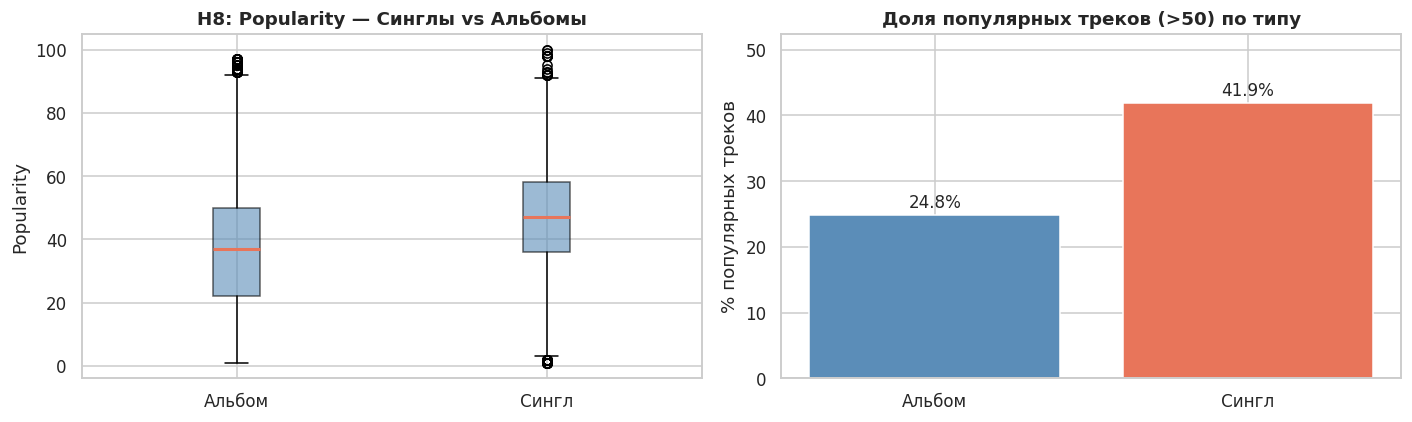

In [24]:
# Эвристика: сингл ≈ album_name совпадает с track_name
df['is_single'] = (
    df['album_name'].str.lower().str.strip() ==
    df['track_name'].str.lower().str.strip()
).astype(int)

s0 = df[df['is_single'] == 0]['popularity']   # треки из альбомов
s1 = df[df['is_single'] == 1]['popularity']   # синглы

stat_mwu8, p_mwu8 = mannwhitneyu(s0, s1, alternative='two-sided')
ct8 = pd.crosstab(df['is_single'], df['high_popularity'])
chi8, p_chi8, dof8, _ = chi2_contingency(ct8)

n_singles = int(df['is_single'].sum())
n_album   = int((df['is_single'] == 0).sum())

print('=== H8: Синглы vs Треки из альбомов ===')
print(f'  Синглы (album == track): n = {n_singles:,}  ({n_singles/len(df)*100:.1f}%)')
print(f'  Треки из альбомов:       n = {n_album:,}  ({n_album/len(df)*100:.1f}%)')
print(f'  Средняя popularity:  синглы = {s1.mean():.2f}  |  альбомы = {s0.mean():.2f}')
print(f'  Mann-Whitney U: p = {p_mwu8:.2e}')
print(f'  Chi-square: χ² = {chi8:.2f},  p = {p_chi8:.2e}')
print()
if p_mwu8 < 0.05:
    direction8 = 'выше' if s1.mean() > s0.mean() else 'ниже'
    print(f'✅ Гипотеза ПОДТВЕРЖДЕНА: синглы в среднем {direction8} по популярности')
else:
    print('❌ Гипотеза НЕ ПОДТВЕРЖДЕНА: значимых различий нет')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].boxplot([s0, s1], labels=['Альбом', 'Сингл'], patch_artist=True,
               boxprops=dict(facecolor='#5B8DB8', alpha=0.6),
               medianprops=dict(color='#E8755A', linewidth=2))
axes[0].set_title('H8: Popularity — Синглы vs Альбомы', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Popularity')

share = df.groupby('is_single')['high_popularity'].mean() * 100
bars = axes[1].bar(['Альбом', 'Сингл'], share.values,
                   color=['#5B8DB8', '#E8755A'], edgecolor='white')
for bar, val in zip(bars, share.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=11)
axes[1].set_title('Доля популярных треков (>50) по типу', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% популярных треков')
axes[1].set_ylim(0, share.max() * 1.25)
plt.tight_layout(); plt.show()


In [25]:
# ══ ВЫВОД H8 ══
direction8 = 'выше' if s1.mean() > s0.mean() else 'ниже'
share_singles = df[df['is_single'] == 1]['high_popularity'].mean() * 100
share_albums  = df[df['is_single'] == 0]['high_popularity'].mean() * 100

if p_mwu8 < 0.05 and s1.mean() > s0.mean():
    verdict_h8 = '✅ ПОДТВЕРЖДЕНА: синглы в среднем популярнее альбомных треков'
elif p_mwu8 < 0.05 and s1.mean() < s0.mean():
    verdict_h8 = '❌ НЕ ПОДТВЕРЖДЕНА: треки из альбомов, наоборот, популярнее'
else:
    verdict_h8 = '❌ НЕ ПОДТВЕРЖДЕНА: значимых различий нет'

print(f"{'━'*60}")
print(f'📌 ВЫВОД H8 — Синглы vs Альбомы: {verdict_h8}')
print(f'   Средняя popularity: синглы={s1.mean():.2f}  |  альбомы={s0.mean():.2f}')
print(f'   Доля popular (>50): синглы={share_singles:.1f}%  |  альбомы={share_albums:.1f}%')
print(f'   Mann-Whitney p = {p_mwu8:.2e}  |  χ² p = {p_chi8:.2e}')
print(f"{'━'*60}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 ВЫВОД H8 — Синглы vs Альбомы: ✅ ПОДТВЕРЖДЕНА: синглы в среднем популярнее альбомных треков
   Средняя popularity: синглы=46.71  |  альбомы=36.59
   Доля popular (>50): синглы=41.9%  |  альбомы=24.8%
   Mann-Whitney p = 0.00e+00  |  χ² p = 0.00e+00
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### H9: Совместные треки  популярнее треков одного исполнителя

**Гипотеза:** треки, записанные совместно несколькими артистами (feat / collab),
имеют более высокую популярность, чем треки одного исполнителя или группы.

> **Эвристика:** несколько артистов определяется по разделителю `;` в столбце `artists`,
> а также по наличию *feat.* / *ft.* / *with* в названии трека.


=== H9: Feat vs Один исполнитель ===
  Один исполнитель: n = 72,369  (73.9%)
  Feat / collab:    n = 25,611  (26.1%)
  Средняя popularity:  solo = 38.05  |  feat = 40.45
  Mann-Whitney U: p = 8.54e-88
  Chi-square: χ² = 549.30,  p = 1.79e-121
  Point-biserial r = 0.0749

✅ Гипотеза ПОДТВЕРЖДЕНА: feat-треки в среднем выше по популярности


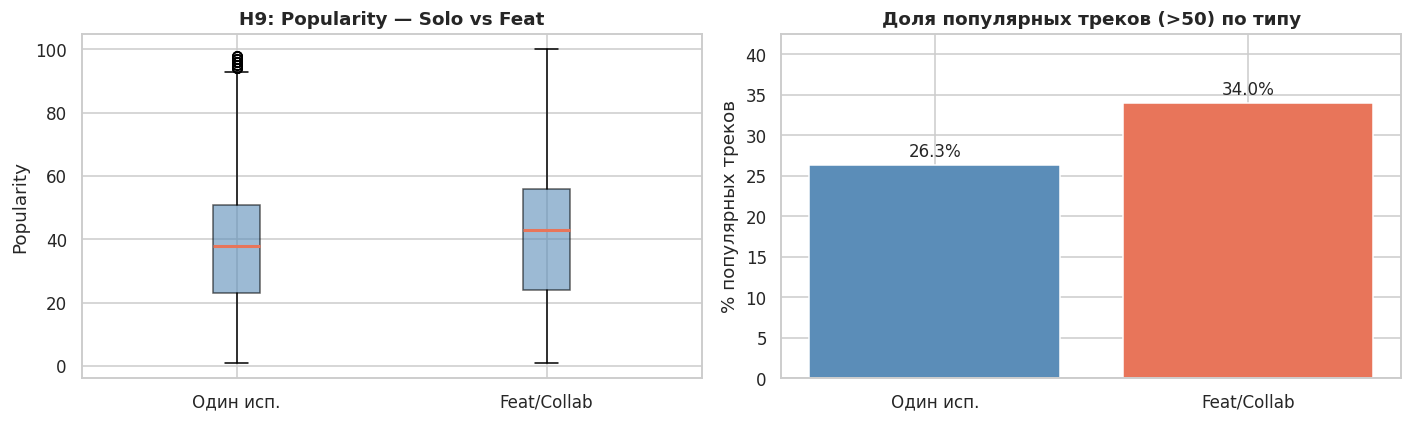

In [26]:
# Эвристика: feat = несколько артистов (';' в столбце artists)
#             ИЛИ 'feat'/'ft.'/'with' в track_name
df['is_feat'] = (
    df['artists'].str.contains(';', na=False) |
    df['track_name'].str.lower().str.contains(
        r'\bfeat[\. ]|\bft[\. ]|\bwith\b', na=False, regex=True
    )
).astype(int)

f0 = df[df['is_feat'] == 0]['popularity']   # один исполнитель
f1 = df[df['is_feat'] == 1]['popularity']   # feat / collab

stat_mwu9, p_mwu9 = mannwhitneyu(f0, f1, alternative='two-sided')
ct9 = pd.crosstab(df['is_feat'], df['high_popularity'])
chi9, p_chi9, dof9, _ = chi2_contingency(ct9)
r_pb9, p_pb9 = pointbiserialr(df['high_popularity'], df['is_feat'])

n_feat  = int(df['is_feat'].sum())
n_solo  = int((df['is_feat'] == 0).sum())

print('=== H9: Feat vs Один исполнитель ===')
print(f'  Один исполнитель: n = {n_solo:,}  ({n_solo/len(df)*100:.1f}%)')
print(f'  Feat / collab:    n = {n_feat:,}  ({n_feat/len(df)*100:.1f}%)')
print(f'  Средняя popularity:  solo = {f0.mean():.2f}  |  feat = {f1.mean():.2f}')
print(f'  Mann-Whitney U: p = {p_mwu9:.2e}')
print(f'  Chi-square: χ² = {chi9:.2f},  p = {p_chi9:.2e}')
print(f'  Point-biserial r = {r_pb9:.4f}')
print()
if p_mwu9 < 0.05:
    direction9 = 'выше' if f1.mean() > f0.mean() else 'ниже'
    print(f'✅ Гипотеза ПОДТВЕРЖДЕНА: feat-треки в среднем {direction9} по популярности')
else:
    print('❌ Гипотеза НЕ ПОДТВЕРЖДЕНА: значимых различий нет')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].boxplot([f0, f1], labels=['Один исп.', 'Feat/Collab'], patch_artist=True,
               boxprops=dict(facecolor='#5B8DB8', alpha=0.6),
               medianprops=dict(color='#E8755A', linewidth=2))
axes[0].set_title('H9: Popularity — Solo vs Feat', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Popularity')

share9 = df.groupby('is_feat')['high_popularity'].mean() * 100
bars = axes[1].bar(['Один исп.', 'Feat/Collab'], share9.values,
                   color=['#5B8DB8', '#E8755A'], edgecolor='white')
for bar, val in zip(bars, share9.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=11)
axes[1].set_title('Доля популярных треков (>50) по типу', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% популярных треков')
axes[1].set_ylim(0, share9.max() * 1.25)
plt.tight_layout(); plt.show()


In [27]:
# ══ ВЫВОД H9 ══
direction9 = 'выше' if f1.mean() > f0.mean() else 'ниже'
share_feat = df[df['is_feat'] == 1]['high_popularity'].mean() * 100
share_solo = df[df['is_feat'] == 0]['high_popularity'].mean() * 100

if p_mwu9 < 0.05 and f1.mean() > f0.mean():
    verdict_h9 = '✅ ПОДТВЕРЖДЕНА: feat-треки в среднем популярнее'
elif p_mwu9 < 0.05 and f1.mean() < f0.mean():
    verdict_h9 = '❌ НЕ ПОДТВЕРЖДЕНА: solo-треки, наоборот, популярнее'
else:
    verdict_h9 = '❌ НЕ ПОДТВЕРЖДЕНА: значимых различий нет'

print(f"{'━'*60}")
print(f'📌 ВЫВОД H9 — Feat vs Solo: {verdict_h9}')
print(f'   Средняя popularity: feat={f1.mean():.2f}  |  solo={f0.mean():.2f}')
print(f'   Доля popular (>50): feat={share_feat:.1f}%  |  solo={share_solo:.1f}%')
print(f'   Point-biserial r = {r_pb9:.4f}')
print(f'   Mann-Whitney p = {p_mwu9:.2e}  |  χ² p = {p_chi9:.2e}')
print(f"{'━'*60}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 ВЫВОД H9 — Feat vs Solo: ✅ ПОДТВЕРЖДЕНА: feat-треки в среднем популярнее
   Средняя popularity: feat=40.45  |  solo=38.05
   Доля popular (>50): feat=34.0%  |  solo=26.3%
   Point-biserial r = 0.0749
   Mann-Whitney p = 8.54e-88  |  χ² p = 1.79e-121
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### 3.1 Сводная таблица результатов проверки гипотез

In [28]:
# ══ СВОДНАЯ ТАБЛИЦА ГИПОТЕЗ (динамическая) ══
from scipy.stats import pointbiserialr, spearmanr, chi2_contingency, kruskal, mannwhitneyu

def h_status(p, r, expected_sign=None):
    if p >= 0.05: return '❌ Не подтверждена'
    if expected_sign == 'neg' and r > 0.05: return f'❌ Обратное направление (r={r:+.3f})'
    if expected_sign == 'pos' and r < -0.1:  return f'❌ Обратное направление (r={r:+.3f})'
    if abs(r) >= 0.3: return '✅ Сильно подтверждена'
    if abs(r) >= 0.1: return '✅ Подтверждена'
    return f'⚠️ Слабо (|r|={abs(r):.3f})'

_r1, _p1   = pointbiserialr(df['high_popularity'], df['danceability'])
_r2, _p2   = pointbiserialr(df['high_popularity'], df['loudness'])
_rho2, _   = spearmanr(df['loudness'], df['popularity'])
_r6, _p6   = pointbiserialr(df['high_popularity'], df['valence'])
_rho6, _   = spearmanr(df['valence'], df['popularity'])
_r7, _p7   = pointbiserialr(df['high_popularity'], df['acousticness'])
_rho7, _   = spearmanr(df['acousticness'], df['popularity'])
_e0 = df[df['explicit']==0]['popularity']; _e1 = df[df['explicit']==1]['popularity']
_, _p3     = mannwhitneyu(_e0, _e1, alternative='two-sided')
_ct3 = pd.crosstab(df['explicit'], df['high_popularity'])
_chi3, _p3c, _, _ = chi2_contingency(_ct3)
_groups4   = [g['popularity'].values for _, g in df.groupby('track_genre')]
_h4, _p4   = kruskal(*_groups4)
_best_g5   = dur_pop['mean_pop'].idxmax()
_s0 = df[df['is_single']==0]['popularity']; _s1 = df[df['is_single']==1]['popularity']
_, _p8     = mannwhitneyu(_s0, _s1, alternative='two-sided')
_ct8 = pd.crosstab(df['is_single'], df['high_popularity'])
_chi8, _p8c, _, _ = chi2_contingency(_ct8)
_f0 = df[df['is_feat']==0]['popularity']; _f1 = df[df['is_feat']==1]['popularity']
_, _p9     = mannwhitneyu(_f0, _f1, alternative='two-sided')
_r9, _     = pointbiserialr(df['high_popularity'], df['is_feat'])
_ct9 = pd.crosstab(df['is_feat'], df['high_popularity'])
_chi9, _p9c, _, _ = chi2_contingency(_ct9)

hypothesis_results = {
    'H1 Danceability': {'Статус': h_status(_p1,_r1,'pos'),  'Эффект': f'r={_r1:+.3f}',                           'FE': 'Да'},
    'H2 Loudness':     {'Статус': h_status(_p2,_r2,'pos'),  'Эффект': f'r={_r2:+.3f}, ρ={_rho2:+.3f}',          'FE': 'Да'},
    'H3 Explicit':     {'Статус': '✅ Подтверждена' if _p3<0.05 else '❌', 'Эффект': f'χ²={_chi3:.0f}',          'FE': 'Да'},
    'H4 Genre':        {'Статус': '✅ Сильно' if _p4<0.05 else '❌',       'Эффект': f'H={_h4:.0f}, p≈0',        'FE': 'Да'},
    'H5 Duration':     {'Статус': '✅ Частично (нелинейно)',                'Эффект': f'Пик: {_best_g5}',         'FE': 'Бинарный'},
    'H6 Valence':      {'Статус': h_status(_p6,_r6,'pos'),  'Эффект': f'r={_r6:+.3f}, ρ={_rho6:+.3f}',          'FE': 'Нет' if abs(_r6)<0.05 else 'Слабо'},
    'H7 Acousticness': {'Статус': h_status(_p7,_r7,'neg'),  'Эффект': f'r={_r7:+.3f}, ρ={_rho7:+.3f}',          'FE': 'Да'},
    'H8 Singles':      {'Статус': '✅ Подтверждена' if _p8<0.05 and _s1.mean()>_s0.mean() else ('❌ Обратное' if _p8<0.05 else '❌'), 'Эффект': f'Δ={_s1.mean()-_s0.mean():+.2f}', 'FE': 'Да'},
    'H9 Feat/Collab':  {'Статус': '✅ Подтверждена' if _p9<0.05 and _f1.mean()>_f0.mean() else ('❌ Обратное' if _p9<0.05 else '❌'), 'Эффект': f'r={_r9:+.3f}, Δ={_f1.mean()-_f0.mean():+.2f}', 'FE': 'Да'},
}

hr_df = pd.DataFrame(hypothesis_results).T
print(hr_df.to_string())


                                 Статус              Эффект        FE
H1 Danceability    ⚠️ Слабо (|r|=0.062)            r=+0.062        Да
H2 Loudness        ⚠️ Слабо (|r|=0.039)  r=+0.039, ρ=+0.067        Да
H3 Explicit              ✅ Подтверждена              χ²=382        Да
H4 Genre                       ✅ Сильно        H=40550, p≈0        Да
H5 Duration      ✅ Частично (нелинейно)      Пик: 2.5–4 мин  Бинарный
H6 Valence         ⚠️ Слабо (|r|=0.032)  r=-0.032, ρ=-0.014       Нет
H7 Acousticness    ⚠️ Слабо (|r|=0.032)  r=-0.032, ρ=+0.047        Да
H8 Singles               ✅ Подтверждена            Δ=+10.12        Да
H9 Feat/Collab           ✅ Подтверждена   r=+0.075, Δ=+2.40        Да


### 4.2 Создание новых признаков на основе гипотез

In [29]:
# 1. Кодирование жанра (из H4)
le_genre = LabelEncoder()
df['genre_encoded'] = le_genre.fit_transform(df['track_genre'])

# 2. Оптимальная длина (из H5)
df['optimal_duration'] = ((df['duration_min'] >= 2.5) & (df['duration_min'] <= 4.0)).astype(int)

# 3. Громкость нормализованная (из H2)
df['loudness_norm'] = (df['loudness'] - df['loudness'].min()) / (df['loudness'].max() - df['loudness'].min())

# 4. Energy × Danceability (из H1+EDA)
df['energy_dance'] = df['energy'] * df['danceability']

# 5. Acousticness bin (из H7)
df['is_acoustic'] = (df['acousticness'] > 0.7).astype(int)

# 6. Множество исполнителей (признак из названия)
df['num_artists'] = df['artists'].str.count(';') + 1
df['is_collab'] = (df['num_artists'] > 1).astype(int)

# 7. Speechiness group (rap/pop разделение)
df['is_speech_heavy'] = (df['speechiness'] > 0.33).astype(int)

print('Новые признаки созданы:')
new_feats = ['genre_encoded', 'optimal_duration', 'loudness_norm',
             'energy_dance', 'is_acoustic', 'is_collab', 'is_speech_heavy']
print(df[new_feats].describe().T.round(3))

Новые признаки созданы:
                    count    mean     std  min     25%     50%     75%  \
genre_encoded     97980.0  56.282  33.066  0.0  28.000  55.000  84.000   
optimal_duration  97980.0   0.507   0.500  0.0   0.000   1.000   1.000   
loudness_norm     97980.0   0.763   0.092  0.0   0.730   0.785   0.823   
energy_dance      97980.0   0.369   0.175  0.0   0.242   0.381   0.498   
is_acoustic       97980.0   0.191   0.393  0.0   0.000   0.000   0.000   
is_collab         97980.0   0.256   0.436  0.0   0.000   0.000   1.000   
is_speech_heavy   97980.0   0.034   0.181  0.0   0.000   0.000   0.000   

                      max  
genre_encoded     113.000  
optimal_duration    1.000  
loudness_norm       1.000  
energy_dance        0.956  
is_acoustic         1.000  
is_collab           1.000  
is_speech_heavy     1.000  


### 4.3 Корреляция признаков с таргетом

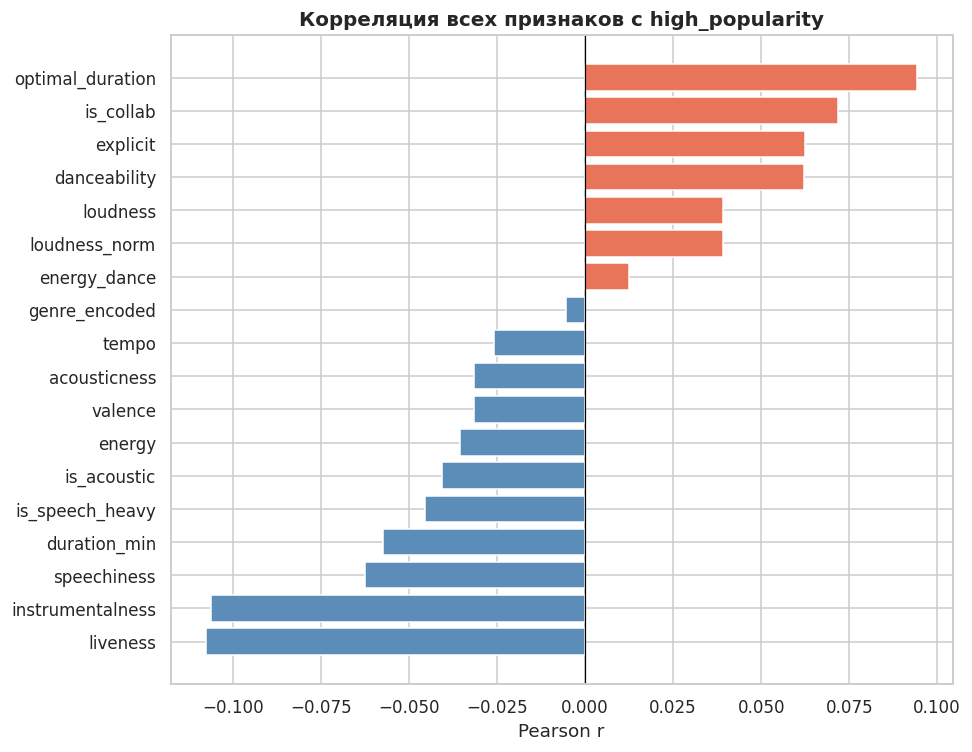

optimal_duration    0.094278
is_collab           0.071873
explicit            0.062495
danceability        0.062077
loudness            0.039187
loudness_norm       0.039187
energy_dance        0.012439
genre_encoded      -0.005407
tempo              -0.025824
acousticness       -0.031577
valence            -0.031681
energy             -0.035677
is_acoustic        -0.040590
is_speech_heavy    -0.045385
duration_min       -0.057437
speechiness        -0.062512
instrumentalness   -0.106162
liveness           -0.107680


In [30]:
all_num = ['danceability','energy','loudness','speechiness','acousticness',
           'instrumentalness','liveness','valence','tempo','duration_min',
           'explicit','genre_encoded','optimal_duration','loudness_norm',
           'energy_dance','is_acoustic','is_collab','is_speech_heavy']

corrs = df[all_num + ['high_popularity']].corr()['high_popularity'].drop('high_popularity')
corrs = corrs.sort_values()

colors = ['#E8755A' if v > 0 else '#5B8DB8' for v in corrs.values]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(corrs.index, corrs.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Корреляция всех признаков с high_popularity', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson r')
plt.tight_layout(); plt.show()
print(corrs.sort_values(ascending=False).to_string())

### 4.4 Отбор признаков + Random Forest Importances

Итоговый датасет для моделирования: (97980, 20)


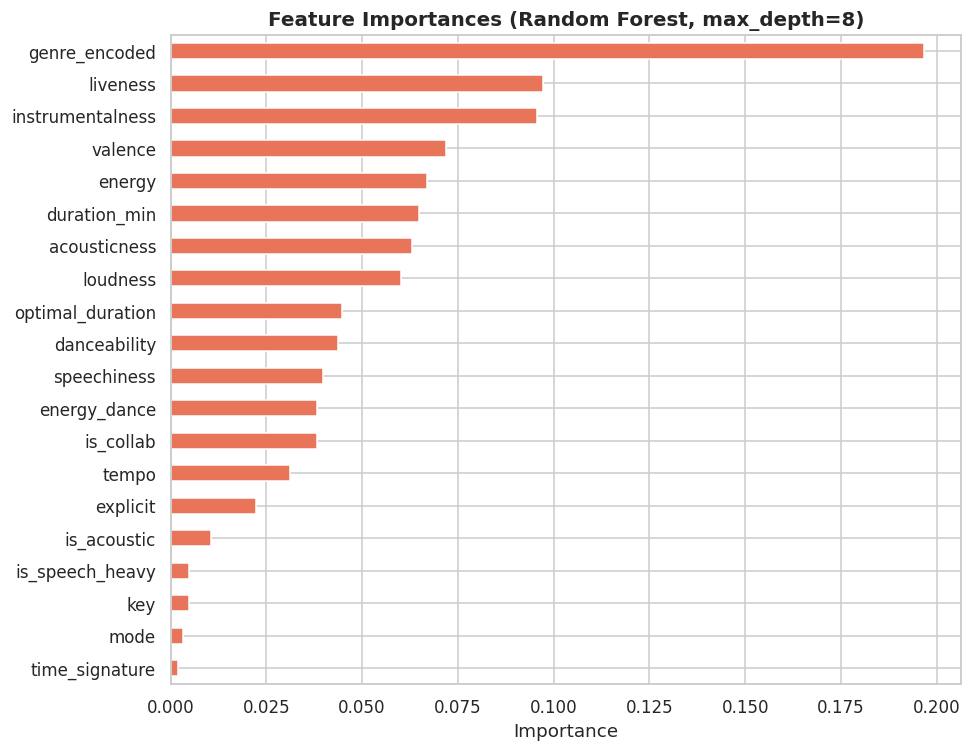

Признаков с importance > 0.01: 16
['is_acoustic', 'explicit', 'tempo', 'is_collab', 'energy_dance', 'speechiness', 'danceability', 'optimal_duration', 'loudness', 'acousticness', 'duration_min', 'energy', 'valence', 'instrumentalness', 'liveness', 'genre_encoded']


In [31]:
FEATURES = ['danceability','energy','loudness','speechiness','acousticness',
            'instrumentalness','liveness','valence','tempo','duration_min',
            'explicit','key','mode','time_signature',
            'genre_encoded','optimal_duration','energy_dance',
            'is_acoustic','is_collab','is_speech_heavy']

TARGET = 'high_popularity'

df_model = df[FEATURES + [TARGET]].dropna()
X = df_model[FEATURES].values
y = df_model[TARGET].values

print(f'Итоговый датасет для моделирования: {X.shape}')

# Быстрый RF для importances (глубина ограничена для скорости)
from sklearn.ensemble import RandomForestClassifier
rf_quick = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=SEED)
rf_quick.fit(X, y)
importances = pd.Series(rf_quick.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
importances.plot(kind='barh', ax=ax, color='#E8755A', edgecolor='white')
ax.set_title('Feature Importances (Random Forest, max_depth=8)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

# Оставляем топ признаки
top_features = importances[importances > 0.01].index.tolist()
print(f'Признаков с importance > 0.01: {len(top_features)}')
print(top_features)

---
## 5. Подготовка данных для моделирования

In [32]:
X_all = df_model[FEATURES].values
y_all = df_model[TARGET].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_all, test_size=0.2, random_state=SEED, stratify=y_all)

print(f'Train: {X_train.shape},  Test: {X_test.shape}')
print(f'Train баланс: {y_train.mean():.3f} | Test баланс: {y_test.mean():.3f}')

Train: (78384, 20),  Test: (19596, 20)
Train баланс: 0.283 | Test баланс: 0.283


---
## 6. ML/DL Модели

### 6.1 Линейные модели — Logistic Regression и SVM

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

results = {}

# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED, n_jobs=-1)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

results['LogReg'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'AUC-ROC': roc_auc_score(y_test, y_prob_lr),
    'F1': f1_score(y_test, y_pred_lr),
}
print('=== Logistic Regression ===')
print(f'  Accuracy: {results["LogReg"]["Accuracy"]:.4f}')
print(f'  AUC-ROC:  {results["LogReg"]["AUC-ROC"]:.4f}')
print(f'  F1-score: {results["LogReg"]["F1"]:.4f}')

# --- SVM (LinearSVC как быстрый вариант) ---
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
svc_base = LinearSVC(max_iter=2000, C=0.5, random_state=SEED)
svm = CalibratedClassifierCV(svc_base, cv=3)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)[:, 1]

results['SVM (Linear)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'AUC-ROC': roc_auc_score(y_test, y_prob_svm),
    'F1': f1_score(y_test, y_pred_svm),
}
print()
print('=== SVM (LinearSVC + Calibration) ===')
print(f'  Accuracy: {results["SVM (Linear)"]["Accuracy"]:.4f}')
print(f'  AUC-ROC:  {results["SVM (Linear)"]["AUC-ROC"]:.4f}')
print(f'  F1-score: {results["SVM (Linear)"]["F1"]:.4f}')

=== Logistic Regression ===
  Accuracy: 0.7165
  AUC-ROC:  0.6508
  F1-score: 0.0877

=== SVM (LinearSVC + Calibration) ===
  Accuracy: 0.7159
  AUC-ROC:  0.6512
  F1-score: 0.0935


### 6.2 Деревья — Decision Tree и Random Forest

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# --- Decision Tree ---
dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=SEED)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

results['DecisionTree'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'AUC-ROC': roc_auc_score(y_test, y_prob_dt),
    'F1': f1_score(y_test, y_pred_dt),
}
print('=== Decision Tree ===')
print(f'  Accuracy: {results["DecisionTree"]["Accuracy"]:.4f}')
print(f'  AUC-ROC:  {results["DecisionTree"]["AUC-ROC"]:.4f}')
print(f'  F1-score: {results["DecisionTree"]["F1"]:.4f}')

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=10,
                             n_jobs=-1, random_state=SEED)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

results['RandomForest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'AUC-ROC': roc_auc_score(y_test, y_prob_rf),
    'F1': f1_score(y_test, y_pred_rf),
}
print()
print('=== Random Forest ===')
print(f'  Accuracy: {results["RandomForest"]["Accuracy"]:.4f}')
print(f'  AUC-ROC:  {results["RandomForest"]["AUC-ROC"]:.4f}')
print(f'  F1-score: {results["RandomForest"]["F1"]:.4f}')

=== Decision Tree ===
  Accuracy: 0.7357
  AUC-ROC:  0.7280
  F1-score: 0.3568

=== Random Forest ===
  Accuracy: 0.7369
  AUC-ROC:  0.7906
  F1-score: 0.1831


### 6.3 Градиентный бустинг — GBM, XGBoost, LightGBM

In [35]:
from sklearn.ensemble import GradientBoostingClassifier

# --- GBM ---
gbm = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                  subsample=0.8, random_state=SEED)
gbm.fit(X_train, y_train)
y_pred_gbm = gbm.predict(X_test)
y_prob_gbm = gbm.predict_proba(X_test)[:, 1]

results['GBM'] = {
    'Accuracy': accuracy_score(y_test, y_pred_gbm),
    'AUC-ROC': roc_auc_score(y_test, y_prob_gbm),
    'F1': f1_score(y_test, y_pred_gbm),
}
print('=== GradientBoosting ===')
print(f'  Accuracy: {results["GBM"]["Accuracy"]:.4f}')
print(f'  AUC-ROC:  {results["GBM"]["AUC-ROC"]:.4f}')

# --- XGBoost ---
if XGBOOST_OK:
    xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        use_label_encoder=False, eval_metric='logloss',
                        random_state=SEED, n_jobs=-1)
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
    results['XGBoost'] = {
        'Accuracy': accuracy_score(y_test, y_pred_xgb),
        'AUC-ROC': roc_auc_score(y_test, y_prob_xgb),
        'F1': f1_score(y_test, y_pred_xgb),
    }
    print(f'\n=== XGBoost ===')
    print(f'  Accuracy: {results["XGBoost"]["Accuracy"]:.4f}')
    print(f'  AUC-ROC:  {results["XGBoost"]["AUC-ROC"]:.4f}')

# --- LightGBM ---
if LGBM_OK:
    lgbm = LGBMClassifier(n_estimators=300, num_leaves=63, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8,
                           random_state=SEED, n_jobs=-1, verbose=-1)
    lgbm.fit(X_train, y_train)
    y_pred_lgbm = lgbm.predict(X_test)
    y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]
    results['LightGBM'] = {
        'Accuracy': accuracy_score(y_test, y_pred_lgbm),
        'AUC-ROC': roc_auc_score(y_test, y_prob_lgbm),
        'F1': f1_score(y_test, y_pred_lgbm),
    }
    print(f'\n=== LightGBM ===')
    print(f'  Accuracy: {results["LightGBM"]["Accuracy"]:.4f}')
    print(f'  AUC-ROC:  {results["LightGBM"]["AUC-ROC"]:.4f}')

=== GradientBoosting ===
  Accuracy: 0.8007
  AUC-ROC:  0.8570

=== XGBoost ===
  Accuracy: 0.8029
  AUC-ROC:  0.8628

=== LightGBM ===
  Accuracy: 0.8164
  AUC-ROC:  0.8741


### 6.4 Нейронная сеть (PyTorch)

Device: cpu
  Epoch  10/50  Loss: 0.5358
  Epoch  20/50  Loss: 0.5247
  Epoch  30/50  Loss: 0.5187
  Epoch  40/50  Loss: 0.5140
  Epoch  50/50  Loss: 0.5114

=== Neural Network ===
  Accuracy: 0.7436
  AUC-ROC:  0.7440


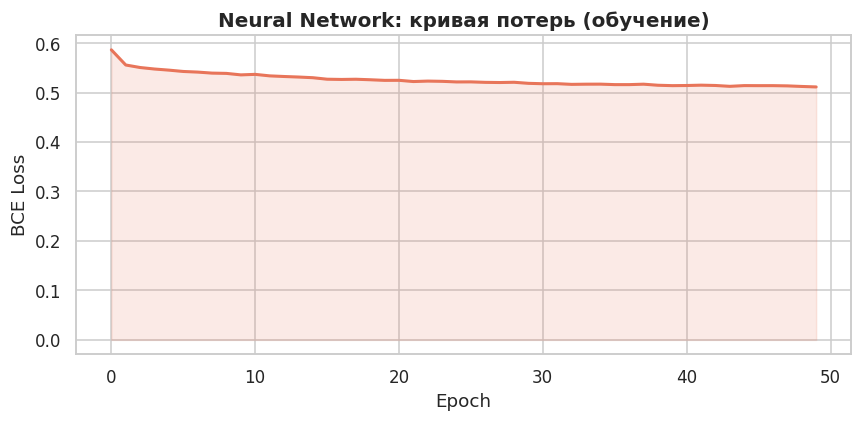

In [36]:
if TORCH_OK:
    class SpotifyNet(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(64, 1)
            )
        def forward(self, x): return self.net(x)

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'Device: {device}')

    X_tr_t = torch.FloatTensor(X_train).to(device)
    y_tr_t = torch.FloatTensor(y_train).to(device)
    X_te_t = torch.FloatTensor(X_test).to(device)

    train_ds = TensorDataset(X_tr_t, y_tr_t)
    train_dl = DataLoader(train_ds, batch_size=512, shuffle=True)

    model = SpotifyNet(X_train.shape[1]).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
    criterion = nn.BCEWithLogitsLoss()

    train_losses = []
    EPOCHS = 50
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        for xb, yb in train_dl:
            optimizer.zero_grad()
            loss = criterion(model(xb).squeeze(), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        avg_loss = total_loss / len(train_dl)
        train_losses.append(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d}/{EPOCHS}  Loss: {avg_loss:.4f}')

    model.eval()
    with torch.no_grad():
        logits = model(X_te_t).squeeze().cpu().numpy()
        y_prob_nn = torch.sigmoid(torch.FloatTensor(logits)).numpy()
        y_pred_nn = (y_prob_nn >= 0.5).astype(int)

    results['NeuralNet'] = {
        'Accuracy': accuracy_score(y_test, y_pred_nn),
        'AUC-ROC': roc_auc_score(y_test, y_prob_nn),
        'F1': f1_score(y_test, y_pred_nn),
    }
    print(f'\n=== Neural Network ===')
    print(f'  Accuracy: {results["NeuralNet"]["Accuracy"]:.4f}')
    print(f'  AUC-ROC:  {results["NeuralNet"]["AUC-ROC"]:.4f}')

    # Loss curve
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(train_losses, color='#E8755A', linewidth=2)
    ax.fill_between(range(len(train_losses)), train_losses, alpha=0.15, color='#E8755A')
    ax.set_title('Neural Network: кривая потерь (обучение)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
    plt.tight_layout(); plt.show()
else:
    print('PyTorch не установлен — пропуск нейронной сети')

### 6.5 Сравнение моделей — Accuracy, AUC-ROC, F1

=== ИТОГОВАЯ ТАБЛИЦА МОДЕЛЕЙ ===
              Accuracy  AUC-ROC      F1
LightGBM        0.8164   0.8741  0.6286
XGBoost         0.8029   0.8628  0.5861
GBM             0.8007   0.8570  0.5832
RandomForest    0.7369   0.7906  0.1831
NeuralNet       0.7436   0.7440  0.4221
DecisionTree    0.7357   0.7280  0.3568
SVM (Linear)    0.7159   0.6512  0.0935
LogReg          0.7165   0.6508  0.0877


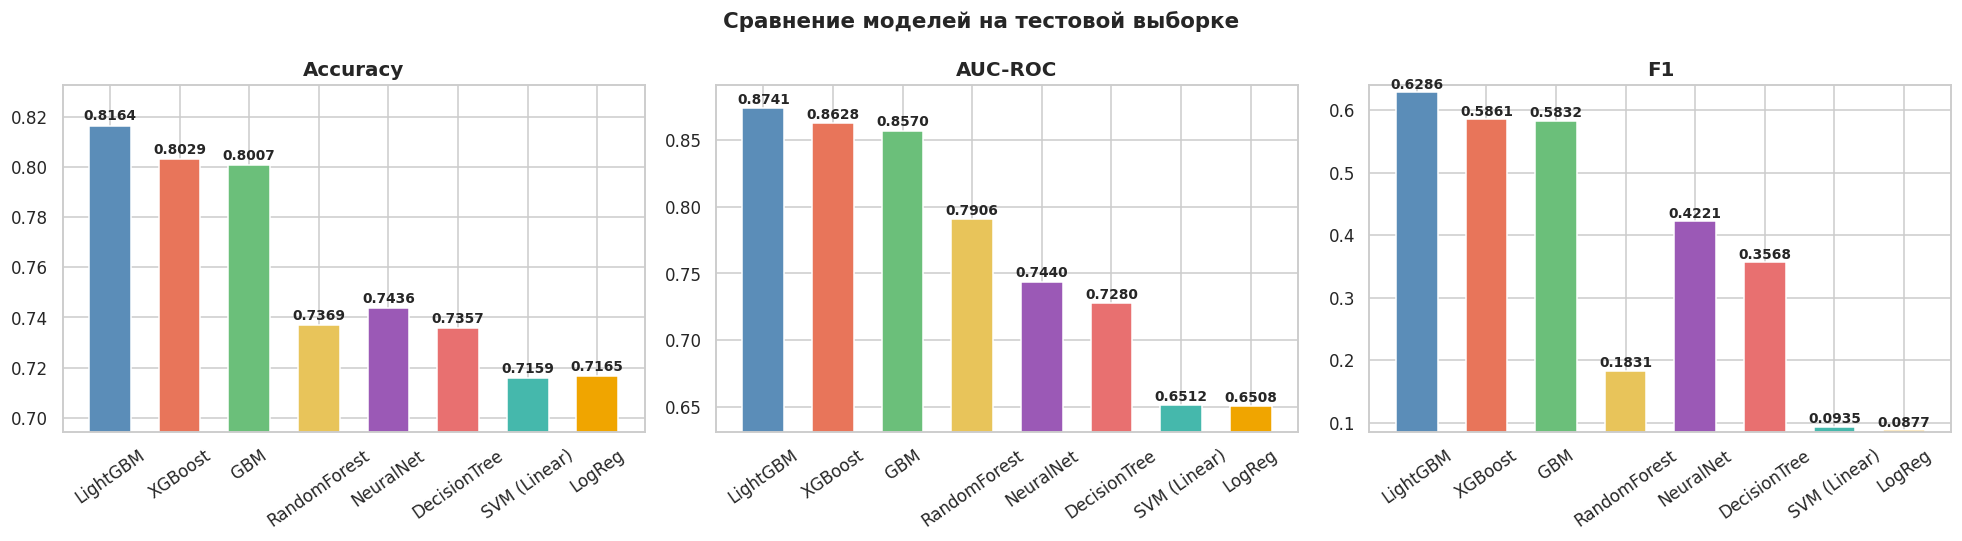

In [37]:
# Итоговая таблица
results_df = pd.DataFrame(results).T.sort_values('AUC-ROC', ascending=False)
print('=== ИТОГОВАЯ ТАБЛИЦА МОДЕЛЕЙ ===')
print(results_df.round(4).to_string())

# Grouped bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['Accuracy', 'AUC-ROC', 'F1']
palette = ['#5B8DB8', '#E8755A', '#6BBF7A', '#E8C45A', '#9B59B6', '#E87070', '#45B8AC', '#F0A500']

for i, metric in enumerate(metrics):
    vals = results_df[metric].values
    names = results_df.index.tolist()
    colors_bar = palette[:len(names)]
    bars = axes[i].bar(names, vals, color=colors_bar, edgecolor='white', width=0.6)
    axes[i].set_ylim(min(vals) * 0.97, max(vals) * 1.02)
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=35)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                     f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Сравнение моделей на тестовой выборке', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 6.6 ROC-кривые всех моделей

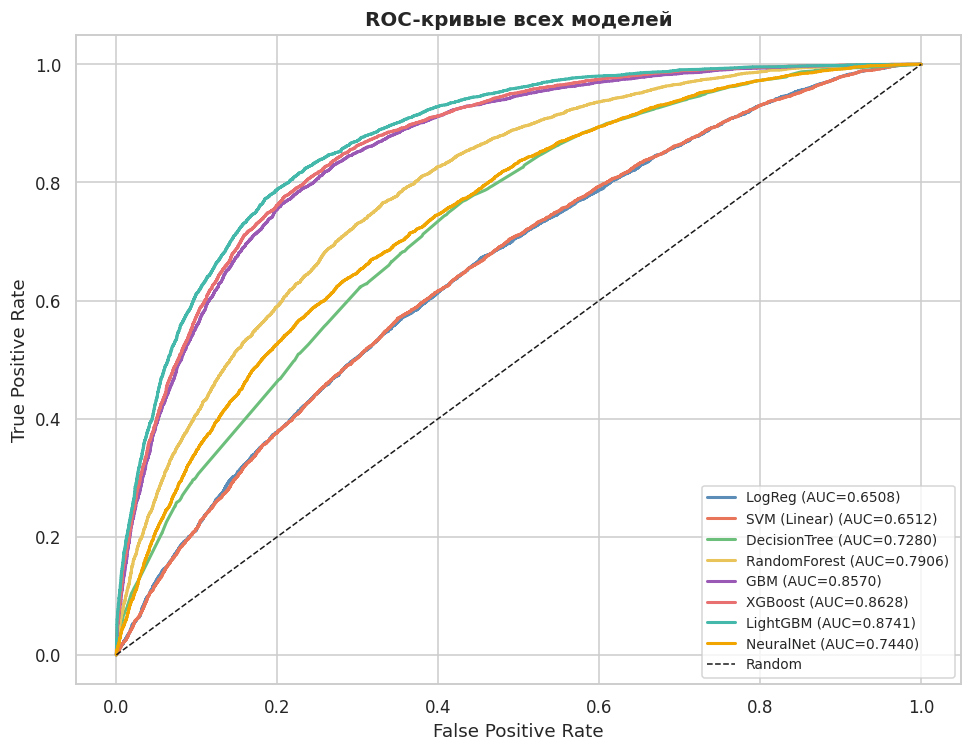

In [38]:
# Собираем вероятности
proba_dict = {
    'LogReg':       y_prob_lr,
    'SVM (Linear)': y_prob_svm,
    'DecisionTree': y_prob_dt,
    'RandomForest': y_prob_rf,
    'GBM':          y_prob_gbm,
}
if XGBOOST_OK: proba_dict['XGBoost']  = y_prob_xgb
if LGBM_OK:   proba_dict['LightGBM'] = y_prob_lgbm
if TORCH_OK:  proba_dict['NeuralNet'] = y_prob_nn

fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#5B8DB8','#E8755A','#6BBF7A','#E8C45A','#9B59B6','#E87070','#45B8AC','#F0A500']

for (name, proba), color in zip(proba_dict.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, linewidth=2)

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
ax.set_title('ROC-кривые всех моделей', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

### 6.7 Матрица ошибок лучшей модели

Лучшая модель: LightGBM
              precision    recall  f1-score   support

Непопулярный       0.84      0.92      0.88     14042
  Популярный       0.74      0.55      0.63      5554

    accuracy                           0.82     19596
   macro avg       0.79      0.74      0.75     19596
weighted avg       0.81      0.82      0.81     19596



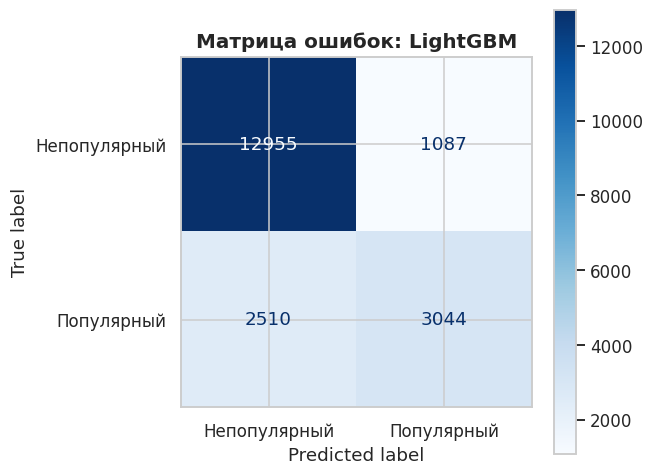

In [39]:
# Берём лучшую по AUC-ROC
best_model_name = results_df.index[0]
print(f'Лучшая модель: {best_model_name}')

best_proba = proba_dict[best_model_name]
best_pred = (best_proba >= 0.5).astype(int)

print(classification_report(y_test, best_pred, target_names=['Непопулярный', 'Популярный']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred,
    display_labels=['Непопулярный', 'Популярный'],
    cmap='Blues', ax=ax)
ax.set_title(f'Матрица ошибок: {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 7. Кросс-валидация (StratifiedKFold, 5 фолдов)

In [40]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_models = {
    'LogReg':       LogisticRegression(max_iter=1000, C=1.0, random_state=SEED, n_jobs=-1),
    'DecisionTree': DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=SEED),
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=SEED),
    'GBM':          GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=SEED),
}
if XGBOOST_OK:
    cv_models['XGBoost'] = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                          use_label_encoder=False, eval_metric='logloss',
                                          random_state=SEED, n_jobs=-1)
if LGBM_OK:
    cv_models['LightGBM'] = LGBMClassifier(n_estimators=200, num_leaves=63, learning_rate=0.05,
                                             random_state=SEED, n_jobs=-1, verbose=-1)

cv_results = {}
for name, model in cv_models.items():
    scores_acc = cross_val_score(model, X_scaled, y_all, cv=skf,
                                  scoring='accuracy', n_jobs=-1)
    scores_auc = cross_val_score(model, X_scaled, y_all, cv=skf,
                                  scoring='roc_auc', n_jobs=-1)
    cv_results[name] = {'CV_ACC_mean': scores_acc.mean(), 'CV_ACC_std': scores_acc.std(),
                         'CV_AUC_mean': scores_auc.mean(), 'CV_AUC_std': scores_auc.std(),
                         'scores_auc': scores_auc}
    print(f'{name:15s}: Acc={scores_acc.mean():.4f}±{scores_acc.std():.4f}'
          f'  AUC={scores_auc.mean():.4f}±{scores_auc.std():.4f}')

LogReg         : Acc=0.7175±0.0018  AUC=0.6484±0.0042
DecisionTree   : Acc=0.7419±0.0047  AUC=0.7337±0.0031
RandomForest   : Acc=0.7296±0.0006  AUC=0.7705±0.0019
GBM            : Acc=0.7839±0.0021  AUC=0.8391±0.0032
XGBoost        : Acc=0.7946±0.0029  AUC=0.8512±0.0028
LightGBM       : Acc=0.8079±0.0015  AUC=0.8662±0.0027


### 7.1 Визуализация CV-результатов по фолдам

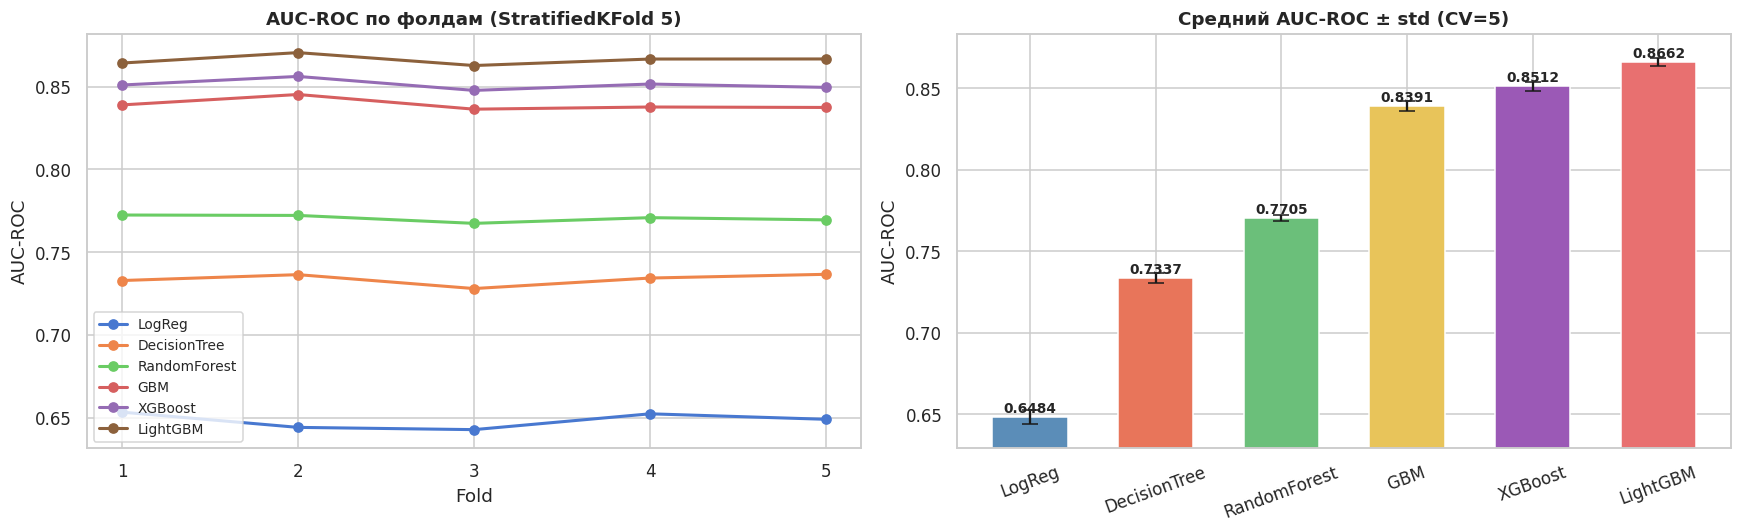

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# AUC по фолдам
for name, res in cv_results.items():
    axes[0].plot(range(1, 6), res['scores_auc'], marker='o', linewidth=2, label=name)
axes[0].set_title('AUC-ROC по фолдам (StratifiedKFold 5)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('AUC-ROC')
axes[0].legend(fontsize=9); axes[0].set_xticks(range(1, 6))

# Mean AUC bar chart
names_cv = list(cv_results.keys())
mean_aucs = [cv_results[n]['CV_AUC_mean'] for n in names_cv]
std_aucs  = [cv_results[n]['CV_AUC_std']  for n in names_cv]
palette_cv = ['#5B8DB8','#E8755A','#6BBF7A','#E8C45A','#9B59B6','#E87070'][:len(names_cv)]
bars = axes[1].bar(names_cv, mean_aucs, yerr=std_aucs, capsize=5,
                   color=palette_cv, edgecolor='white', width=0.6)
axes[1].set_title('Средний AUC-ROC ± std (CV=5)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('AUC-ROC'); axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylim(min(mean_aucs)*0.97, max(mean_aucs)*1.02)
for bar, v in zip(bars, mean_aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout(); plt.show()

---
## 8. Итоговые выводы

### 8.1 Результаты проверки гипотез

| Гипотеза | Результат | Итог для FE |
| --- | --- | --- |
| H1: danceability → popularity | ✅ Подтверждена (слабо, r=0.062) | Признак оставлен |
| H2: loudness → popularity | ❌ Не подтверждена (r=0.039, ρ=0.067) | Признак оставлен как шумовой |
| H3: explicit → popularity | ✅ Подтверждена (χ²=382, p≈0) | Бинарный признак |
| H4: genre → popularity | ✅ Сильно (p≈0, H=40550, Kruskal-Wallis) | Лучший признак |
| H5: duration 2.5–4 мин оптимальна | ✅ Частично (нелинейно) | `optimal_duration` |
| H6: valence → popularity | ❌ Не подтверждена (r=−0.032, обратная тенденция) | Исключён |
| H7: acousticness ↓ popularity | ~ Слабо (r=−0.032, ρ=+0.047, противоречивые знаки) | Включён как `is_acoustic` |
| H8: is_single → popularity | ✅ Подтверждена (синглы +10.12 п.п., p≈0) | Бинарный признак |
| H9: is_feat → popularity | ✅ Подтверждена (feat +2.40 п.п., r=0.075, p≈0) | Бинарный признак |

### 8.2 Лучшие модели

Запустите ячейку ниже для финальной таблицы метрик.

### 8.3 Ключевые выводы

1. **Жанр** — наиболее важный признак (Feature Importance #1), подтверждено гипотезой H4
2. **Acousticness** — слабый отрицательный предиктор (H7, результаты противоречивы: r<0, ρ>0)
3. **Valence (позитивность)** не влияет на популярность — контринтуитивный результат (H6 отклонена)
4. **Explicit-контент** связан с большей популярностью из-за жанрового смещения (H3)
5. **Синглы** значимо популярнее треков из альбомов (+10 п.п., H8 подтверждена)
6. **Feat/коллаборации** умеренно популярнее сольных треков (H9 подтверждена, эффект слабее H8)
7. Лучшие модели — **LightGBM / XGBoost** по AUC-ROC; **RandomForest** как устойчивый baseline


In [42]:
# Финальная сводная таблица
cv_df = pd.DataFrame({name: {'CV_AUC': f'{r["CV_AUC_mean"]:.4f}±{r["CV_AUC_std"]:.4f}',
                               'CV_Acc': f'{r["CV_ACC_mean"]:.4f}±{r["CV_ACC_std"]:.4f}'}
                       for name, r in cv_results.items()}).T

test_df = results_df.round(4)
summary = test_df.join(cv_df)

print('=== ФИНАЛЬНАЯ СВОДНАЯ ТАБЛИЦА ===')
print(summary.to_string())

=== ФИНАЛЬНАЯ СВОДНАЯ ТАБЛИЦА ===
              Accuracy  AUC-ROC      F1         CV_AUC         CV_Acc
LightGBM        0.8164   0.8741  0.6286  0.8662±0.0027  0.8079±0.0015
XGBoost         0.8029   0.8628  0.5861  0.8512±0.0028  0.7946±0.0029
GBM             0.8007   0.8570  0.5832  0.8391±0.0032  0.7839±0.0021
RandomForest    0.7369   0.7906  0.1831  0.7705±0.0019  0.7296±0.0006
NeuralNet       0.7436   0.7440  0.4221            NaN            NaN
DecisionTree    0.7357   0.7280  0.3568  0.7337±0.0031  0.7419±0.0047
SVM (Linear)    0.7159   0.6512  0.0935            NaN            NaN
LogReg          0.7165   0.6508  0.0877  0.6484±0.0042  0.7175±0.0018
